In [1]:
%pdb on

Automatic pdb calling has been turned ON


# Non-pregnant anemia prevalence and DALYs averted by fortification

We take a "multiplication model" approach here, shifting continuous hemoglobin (as estimated
by GBD) and seeing what impact that has on anemia and therefore YLDs.

It's important to note that we directly use hemoglobin estimates, which are the first step
of the GBD anemia estimation pipeline. The risks and causes that are related to anemia are
all calculated downstream from this.

In [2]:
import gbd_mapping
import pathlib
import pandas as pd, numpy as np
import vivarium_inputs
from vivarium_inputs import utility_data, globals as vi_globals, utilities as vi_utils
from vivarium_gbd_access import gbd
import warnings, loguru
from lsff_utils import config_utils
from lsff_utils.hemoglobin_distribution import hemoglobin_pdf_from_mean_sd, hemoglobin_cdf_from_mean_sd

from vivarium_inputs.validation.raw import DataDoesNotExistError, DataAbnormalError
from tqdm.notebook import tqdm

Config: 'input_data:
    cache_data:
        base: True
    intermediary_data_cache_path:
        base: /share/scratch/users/{username}/cache'
Cache Dir: '/share/scratch/users/zmbc/cache'


In [3]:
pd.set_option("display.max_columns", 30)

In [4]:
warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning)

In [5]:
location = "nigeria"
vehicle = "bouillon"

In [6]:
# Parameters
location = "india"
vehicle = "rice"


In [7]:
intervention_scenarios = config_utils.get_config()["custom_intervention_scenarios"].get(
    location, ["intervention"]
)
intervention_scenarios

['intervention']

## Setup and scenarios

In [8]:
DRAWS = [
    f"draw_{i}" for i in range(500)
]  # NOTE: Some GBD 2021 things return 1,000 but others don't

In [9]:
effective_coverage_baseline = pd.read_csv(
    f"../0100_data_prep/results/iron/{vehicle}/baseline_fortification/effective_coverage/{location}.csv"
)
assert (effective_coverage_baseline.vehicle_name == vehicle).all()
effective_coverage_baseline = effective_coverage_baseline.drop(columns=["vehicle_name"])
effective_coverage_baseline

,wealth_quintile,sex,age_start,age_end,value
0,1,Female,0,5,0.295892
1,1,Female,5,15,0.388951
2,1,Female,15,30,0.340944
3,1,Female,30,50,0.368677
4,1,Female,50,125,0.385878
5,1,Male,0,5,0.302019
6,1,Male,5,15,0.392069
7,1,Male,15,30,0.363008
8,1,Male,30,50,0.355872
9,1,Male,50,125,0.380607


In [10]:
def expand(df):
    for col in sorted(list(set(df.columns) - {"value"})):
        if df[col].isnull().any():
            df = pd.concat(
                [
                    df[df[col].notnull()],
                    *[
                        df[df[col].isnull()].assign(**{col: value})
                        for value in df[df[col].notnull()][col].unique()
                    ],
                ]
            )

    return df

In [11]:
for col, fill_value in [("age_start", 0), ("age_end", 125)]:
    if col not in effective_coverage_baseline.columns:
        effective_coverage_baseline[col] = fill_value
    else:
        effective_coverage_baseline[col] = effective_coverage_baseline[col].fillna(
            fill_value
        )

In [12]:
effective_coverage_baseline = expand(effective_coverage_baseline)
effective_coverage_baseline

,wealth_quintile,sex,age_start,age_end,value
0,1,Female,0,5,0.295892
1,1,Female,5,15,0.388951
2,1,Female,15,30,0.340944
3,1,Female,30,50,0.368677
4,1,Female,50,125,0.385878
5,1,Male,0,5,0.302019
6,1,Male,5,15,0.392069
7,1,Male,15,30,0.363008
8,1,Male,30,50,0.355872
9,1,Male,50,125,0.380607


In [13]:
effective_coverage_intervention = pd.concat(
    [
        pd.read_csv(
            f"../0100_data_prep/results/iron/{vehicle}/{intervention_scenario}/intervention_fortification/effective_coverage/{location}.csv"
        ).assign(scenario=intervention_scenario)
        for intervention_scenario in intervention_scenarios
    ]
)
assert (effective_coverage_intervention.vehicle_name == vehicle).all()
effective_coverage_intervention = effective_coverage_intervention.drop(
    columns=["vehicle_name"]
)
effective_coverage_intervention

,sex,age_start,age_end,wealth_quintile,value,scenario
0,Female,0,5,1,0.295892,intervention
1,Female,0,5,2,0.299771,intervention
2,Female,0,5,3,0.280152,intervention
3,Female,0,5,4,0.241038,intervention
4,Female,0,5,5,0.138029,intervention
5,Female,5,15,1,0.388951,intervention
6,Female,5,15,2,0.376756,intervention
7,Female,5,15,3,0.348171,intervention
8,Female,5,15,4,0.300916,intervention
9,Female,5,15,5,0.171419,intervention


In [14]:
for col, fill_value in [("age_start", 0), ("age_end", 125)]:
    if col not in effective_coverage_intervention.columns:
        effective_coverage_intervention[col] = fill_value
    else:
        effective_coverage_intervention[col] = effective_coverage_intervention[
            col
        ].fillna(fill_value)

In [15]:
effective_coverage_intervention = expand(effective_coverage_intervention)
effective_coverage_intervention

,sex,age_start,age_end,wealth_quintile,value,scenario
0,Female,0,5,1,0.295892,intervention
1,Female,0,5,2,0.299771,intervention
2,Female,0,5,3,0.280152,intervention
3,Female,0,5,4,0.241038,intervention
4,Female,0,5,5,0.138029,intervention
5,Female,5,15,1,0.388951,intervention
6,Female,5,15,2,0.376756,intervention
7,Female,5,15,3,0.348171,intervention
8,Female,5,15,4,0.300916,intervention
9,Female,5,15,5,0.171419,intervention


In [16]:
population = pd.read_csv(
    f"../0100_data_prep/results/population/stratified/{location}.csv"
)

In [17]:
non_pregnant_pop = population.pipe(lambda df: df[df.pregnant == "not_pregnant"]).drop(
    columns="pregnant"
)
non_pregnant_pop = non_pregnant_pop.set_index(
    [c for c in non_pregnant_pop.columns if c != "value"]
).value
non_pregnant_pop

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  49649.700497
                               2                  43575.622144
                               3                  38689.356750
                               4                  36440.833935
                               5                  29202.585338
                                                      ...     
Male    95.0       125.000000  1                  15176.692284
                               2                  15848.509818
                               3                  16370.176208
                               4                  17265.313670
                               5                  21289.473456
Name: value, Length: 250, dtype: float64

In [18]:
# example_sex = "Female"
# example_age_start = 25
# example_age_end = 30
# example_wealth_quintile = 1
example_sex = "Male"
example_age_start = 10
example_age_end = 15
example_wealth_quintile = 3
example_tuple = (
    example_sex,
    example_age_start,
    example_age_end,
    example_wealth_quintile,
)

In [19]:
population.set_index(["sex", "age_start", "age_end"]).loc[
    (example_sex, example_age_start, example_age_end)
].value.sum()

69203605.45954193

In [20]:
non_pregnant_pop.loc[(example_sex, example_age_start, example_age_end)][1]

18103915.95143764

In [21]:
non_pregnant_pop.loc[(example_sex, example_age_start, example_age_end)].sum()

69203605.45954193

In [22]:
population_age_groups = (
    non_pregnant_pop.reset_index()[["age_start", "age_end"]]
    .drop_duplicates()
    .sort_values("age_start")
)
population_age_groups

,age_start,age_end
0,0.000000,0.019178
5,0.019178,0.076712
10,0.076712,0.500000
15,0.500000,1.000000
20,1.000000,2.000000
25,2.000000,5.000000
30,5.000000,10.000000
35,10.000000,15.000000
40,15.000000,20.000000
45,20.000000,25.000000


In [23]:
def map_to_population_age_groups(df):
    result = (
        population_age_groups.merge(df, how="cross", suffixes=("", "_orig"))
        .pipe(
            lambda df: df[
                (df.age_end <= df.age_end_orig) & (df.age_start >= df.age_start_orig)
            ]
        )
        .drop(columns=["age_start_orig", "age_end_orig"])
    )
    return result

In [24]:
effective_coverage_baseline = (
    map_to_population_age_groups(effective_coverage_baseline)
    .set_index([c for c in effective_coverage_baseline.columns if c != "value"])
    .value
)
effective_coverage_intervention = (
    map_to_population_age_groups(effective_coverage_intervention)
    .set_index([c for c in effective_coverage_intervention.columns if c != "value"])
    .value
)

In [25]:
if "sex" not in effective_coverage_baseline.index.names:
    # Assume does not vary
    effective_coverage_baseline = pd.concat(
        [
            effective_coverage_baseline.reset_index()
            .assign(sex="Female")
            .set_index(["wealth_quintile", "sex", "age_start", "age_end"])
            .value,
            effective_coverage_baseline.reset_index()
            .assign(sex="Male")
            .set_index(["wealth_quintile", "sex", "age_start", "age_end"])
            .value,
        ]
    )

In [26]:
effective_coverage_baseline = (
    effective_coverage_baseline.reset_index()
    .set_index(["sex", "age_start", "age_end", "wealth_quintile"])
    .value
)

In [27]:
if "sex" not in effective_coverage_intervention.index.names:
    # Assume does not vary
    effective_coverage_intervention = pd.concat(
        [
            effective_coverage_intervention.to_frame()
            .assign(sex="Female")
            .set_index("sex", append=True)
            .reorder_levels(["sex", "age_start", "age_end", "wealth_quintile"])
            .value,
            effective_coverage_intervention.to_frame()
            .assign(sex="Male")
            .set_index("sex", append=True)
            .reorder_levels(["sex", "age_start", "age_end", "wealth_quintile"])
            .value,
        ]
    )

In [28]:
effective_coverage_intervention = (
    effective_coverage_intervention.reorder_levels(["sex", "age_start", "age_end", "wealth_quintile", "scenario"])
)

In [29]:
effective_coverage_baseline.loc[example_tuple]

0.3416836751607619

In [30]:
effective_coverage_intervention.loc[example_tuple]

scenario
intervention    0.341684
Name: value, dtype: float64

In [31]:
def reshape_to_vivarium_format(df, location):
    df = vi_utils.reshape(df, value_cols=[c for c in df.columns if "draw_" in c])
    df = vi_utils.scrub_gbd_conventions(df, location)
    df = vi_utils.split_interval(df, interval_column="age", split_column_prefix="age")
    df = vi_utils.split_interval(df, interval_column="year", split_column_prefix="year")
    df = vi_utils.sort_hierarchical_data(df)
    df.index = df.index.droplevel("location")
    return df

## Pull GBD hemoglobin distribution statistics

In [32]:
me_ids = {
    "hemoglobin_mean": 10487,
    "hemoglobin_sd": 10488,
}

In [33]:
def get_modelable_entity_draws(me_id, location):
    location_id = utility_data.get_location_id(location.title())
    result = gbd.get_modelable_entity_draws(
        me_id=me_id, location_id=location_id, year_id=2021
    )
    return (
        reshape_to_vivarium_format(result, location.title())
        .droplevel(
            [
                "year_start",
                "year_end",
                "measure_id",
                "metric_id",
                "model_version_id",
                "modelable_entity_id",
            ]
        )[DRAWS]
        .copy()
    )

In [34]:
gbd_hgb_mean = get_modelable_entity_draws(me_ids["hemoglobin_mean"], location)
gbd_hgb_mean

________________________________________________________________________________
[Memory] Calling vivarium_gbd_access.gbd.get_modelable_entity_draws...
get_modelable_entity_draws(me_id=10487, location_id=163, year_id=2021)


/mnt/share/homes/zmbc/src/vivarium_gates_lsff_by_wealth_quintile/.venv/lib/python3.11/site-packages/ihme_cc_rules_client/lib/rules_manager.py:224: UnrecognizedRuleWarning: Rules API returned unrecognized rule: EPI_PASS_GET_RESULTS_TO_GET_ESTIMATES. The installed ihme_cc_rules_client package (version 3.15.2) is likely outdated and should be upgraded. If you see this warning in a central environment, please submit a Help Desk ticket for Central Comp: https://helpdesk.ihme.washington.edu
  warnings.warn(
/mnt/share/homes/zmbc/src/vivarium_gates_lsff_by_wealth_quintile/.venv/lib/python3.11/site-packages/ihme_cc_rules_client/lib/rules_manager.py:224: UnrecognizedRuleWarning: Rules API returned unrecognized rule: STGPR_PASS_GET_RESULTS_TO_GET_ESTIMATES. The installed ihme_cc_rules_client package (version 3.15.2) is likely outdated and should be upgraded. If you see this warning in a central environment, please submit a Help Desk ticket for Central Comp: https://helpdesk.ihme.washington.edu
 

/mnt/share/homes/zmbc/src/vivarium_gates_lsff_by_wealth_quintile/.venv/lib/python3.11/site-packages/ihme_cc_rules_client/lib/rules_manager.py:224: UnrecognizedRuleWarning: Rules API returned unrecognized rule: EPI_PASS_GET_RESULTS_TO_GET_ESTIMATES. The installed ihme_cc_rules_client package (version 3.15.2) is likely outdated and should be upgraded. If you see this warning in a central environment, please submit a Help Desk ticket for Central Comp: https://helpdesk.ihme.washington.edu
  warnings.warn(
/mnt/share/homes/zmbc/src/vivarium_gates_lsff_by_wealth_quintile/.venv/lib/python3.11/site-packages/ihme_cc_rules_client/lib/rules_manager.py:224: UnrecognizedRuleWarning: Rules API returned unrecognized rule: STGPR_PASS_GET_RESULTS_TO_GET_ESTIMATES. The installed ihme_cc_rules_client package (version 3.15.2) is likely outdated and should be upgraded. If you see this warning in a central environment, please submit a Help Desk ticket for Central Comp: https://helpdesk.ihme.washington.edu
 

_______________________________________get_modelable_entity_draws - 6.3s, 0.1min


draw_0      draw_1      draw_2      draw_3  \
sex    age_start age_end                                                      
Female 0.000000  0.019178    141.027303  141.174892  143.047093  142.497768   
       0.019178  0.076712    128.185915  129.096397  129.130806  127.546092   
       0.076712  0.500000    103.541148  104.218523  102.321094  104.327579   
       0.500000  1.000000    101.917809   99.823676  100.483745  100.428266   
       1.000000  2.000000    101.808200  103.457343  102.146844  103.058795   
       2.000000  5.000000    106.297867  106.219133  105.789212  107.260720   
       5.000000  10.000000   112.932920  111.768831  112.598540  114.147894   
       10.000000 15.000000   115.889117  117.854010  116.651884  116.435834   
       15.000000 20.000000   117.312802  117.869717  117.696658  118.290512   
       20.000000 25.000000   118.617583  117.381244  117.562883  116.463839   
       25.000000 30.000000   118.136225  118.984193  118.330466  117.484197   
       30.000000 35.000000   118.468947  117.409679  117.886880  119.228899   
       35.000000 40.000000   117.893922  117.756202  118.469227  118.035053   
       40.000000 45.000000   117.705099  117.438677  117.891058  117.526008   
       45.000000 50.000000   118.863416  118.956356  117.862423  118.694166   
       50.000000 55.000000   117.380298  115.684488  117.082839  117.521103   
       55.000000 60.000000   115.610201  115.858632  116.824778  116.971145   
       60.000000 65.000000   115.852172  115.273742  114.679645  115.057166   
       65.000000 70.000000   112.799956  114.029249  112.513289  113.319053   
       70.000000 75.000000   111.763028  110.907571  111.248801  110.229346   
       75.000000 80.000000   106.694860  105.688161  106.061586  105.665603   
       80.000000 85.000000   105.375787  105.408475  105.314517  107.634883   
       85.000000 90.000000   100.573661  100.988738   98.813280   99.706145   
       90.000000 95.000000    97.373246   97.761692   97.824092   97.656022   
       95.000000 125.000000   95.150708   95.688588   94.653440   94.380913   
Male   0.000000  0.019178    146.600654  149.103908  146.074897  145.748027   
       0.019178  0.076712    128.593451  128.987080  131.564522  129.046613   
       0.076712  0.500000    102.882001  103.484281  102.379468  102.302975   
       0.500000  1.000000     98.720550  100.044084   99.267918  100.076804   
       1.000000  2.000000    101.799264  101.036897  102.067002  102.340244   
       2.000000  5.000000    107.195733  107.108687  106.303427  107.176671   
       5.000000  10.000000   115.943763  116.573107  114.252198  113.966774   
       10.000000 15.000000   125.861685  126.103005  123.731518  125.853467   
       15.000000 20.000000   138.148186  139.196158  138.577766  140.412738   
       20.000000 25.000000   145.705670  143.628038  144.447657  145.036625   
       25.000000 30.000000   143.206791  144.192168  144.708908  142.243978   
       30.000000 35.000000   143.104472  145.407658  144.512082  143.314688   
       35.000000 40.000000   143.022415  141.891966  143.895938  141.822267   
       40.000000 45.000000   142.575032  141.418982  142.295188  141.503041   
       45.000000 50.000000   141.450799  142.687529  139.176123  140.952480   
       50.000000 55.000000   138.187591  140.164931  139.259715  141.275545   
       55.000000 60.000000   135.036605  134.464782  134.025679  133.016133   
       60.000000 65.000000   131.931505  132.888573  130.701815  131.483537   
       65.000000 70.000000   128.500505  127.922563  128.410141  128.344826   
       70.000000 75.000000   122.092349  122.015506  121.558645  122.075910   
       75.000000 80.000000   113.648012  114.150699  114.133169  113.393346   
       80.000000 85.000000   111.213129  111.511647  111.224695  113.696862   
       85.000000 90.000000   108.957315  109.468162  107.835589  108.453981   
       90.000000 95.000000   104.826207  102.838567  103.076523  105.765753   
    

In [35]:
gbd_hgb_mean.loc[("Female", 25, 30)].mean()

117.6864790279587

In [36]:
hemoglobin_mean_disparities = pd.read_csv(
    f"../0100_data_prep/results/hemoglobin/mean_disparities/{location}.csv"
)
hemoglobin_mean_disparities = (
    map_to_population_age_groups(
        hemoglobin_mean_disparities[
            hemoglobin_mean_disparities.pregnant == "not_pregnant"
        ].drop(columns=["pregnant"])
    )
    .set_index(["sex", "age_start", "age_end", "wealth_quintile"])
    .value
)
hemoglobin_mean_disparities

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  103.655561
                               2                  105.257986
                               3                  105.397530
                               4                  106.765336
                               5                  107.989017
                                                     ...    
Male    95.0       125.000000  1                  115.022635
                               2                  116.108207
                               3                  116.488978
                               4                  117.310740
                               5                  118.402649
Name: value, Length: 250, dtype: float64

In [37]:
wealth_quintile_probabilities = pd.read_csv(
    f"../0100_data_prep/results/wealth_quintile_probabilities/{location}.csv"
)
wealth_quintile_probabilities

,sex,age_start,age_end,pregnant,1,2,3,4,5
0,Female,0.0,5.0,not_pregnant,0.251317,0.220571,0.195838,0.184456,0.147818
1,Female,5.0,15.0,not_pregnant,0.269038,0.219459,0.193766,0.172569,0.145167
2,Female,15.0,30.0,not_pregnant,0.177853,0.202279,0.211418,0.210441,0.198009
3,Female,15.0,30.0,pregnant,0.221117,0.222530,0.215087,0.182296,0.158970
4,Female,30.0,50.0,not_pregnant,0.172597,0.187138,0.199031,0.213495,0.227738
5,Female,30.0,50.0,pregnant,0.316131,0.181401,0.129805,0.169147,0.203517
6,Female,50.0,125.0,not_pregnant,0.188708,0.187540,0.191253,0.199636,0.232863
7,Male,0.0,5.0,not_pregnant,0.242600,0.215610,0.200229,0.183923,0.157639
8,Male,5.0,15.0,not_pregnant,0.261604,0.217675,0.190718,0.176545,0.153458
9,Male,15.0,30.0,not_pregnant,0.169172,0.205794,0.214029,0.208330,0.202675


In [38]:
wealth_quintile_probabilities = map_to_population_age_groups(
    wealth_quintile_probabilities[
        wealth_quintile_probabilities.pregnant == "not_pregnant"
    ].drop(columns=["pregnant"])
).set_index(["sex", "age_start", "age_end"])
wealth_quintile_probabilities.columns.name = "wealth_quintile"
wealth_quintile_probabilities = wealth_quintile_probabilities.stack()
# TODO: Store wealth quintile probabilities without using numbers as columns
wealth_quintile_probabilities = (
    wealth_quintile_probabilities.rename("value")
    .reset_index()
    .assign(wealth_quintile=lambda df: df.wealth_quintile.astype(int))
    .set_index(wealth_quintile_probabilities.index.names)
    .value
)
wealth_quintile_probabilities

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  0.251317
                               2                  0.220571
                               3                  0.195838
                               4                  0.184456
                               5                  0.147818
                                                    ...   
Male    95.0       125.000000  1                  0.176575
                               2                  0.184392
                               3                  0.190461
                               4                  0.200876
                               5                  0.247696
Name: value, Length: 250, dtype: float64

In [39]:
assert np.allclose(
    wealth_quintile_probabilities.groupby(["sex", "age_start", "age_end"]).sum(), 1.0
)

In [40]:
def distribute_by_disparities(df, disparities):
    pre_disparity_groups = (
        df.mul(wealth_quintile_probabilities, axis=0)
        .groupby([c for c in df.index.names if c != "wealth_quintile"])
        .sum()
    )
    print("Before distributing by disparities:")
    display(pre_disparity_groups)

    df = df.mul(disparities, axis=0)

    scale_factor = (
        pre_disparity_groups
        / df.mul(wealth_quintile_probabilities, axis=0)
        .groupby([c for c in df.index.names if c != "wealth_quintile"])
        .sum()
    )
    print(f"Scale factor: {scale_factor}")

    df = df * scale_factor

    assert np.allclose(
        df.mul(wealth_quintile_probabilities, axis=0)
        .groupby([c for c in df.index.names if c != "wealth_quintile"])
        .sum(),
        pre_disparity_groups,
    )

    return df

In [41]:
hgb_mean = distribute_by_disparities(gbd_hgb_mean, hemoglobin_mean_disparities)

Before distributing by disparities:


draw_0      draw_1      draw_2      draw_3  \
sex    age_start age_end                                                      
Female 0.000000  0.019178    141.027303  141.174892  143.047093  142.497768   
       0.019178  0.076712    128.185915  129.096397  129.130806  127.546092   
       0.076712  0.500000    103.541148  104.218523  102.321094  104.327579   
       0.500000  1.000000    101.917809   99.823676  100.483745  100.428266   
       1.000000  2.000000    101.808200  103.457343  102.146844  103.058795   
       2.000000  5.000000    106.297867  106.219133  105.789212  107.260720   
       5.000000  10.000000   112.932920  111.768831  112.598540  114.147894   
       10.000000 15.000000   115.889117  117.854010  116.651884  116.435834   
       15.000000 20.000000   117.312802  117.869717  117.696658  118.290512   
       20.000000 25.000000   118.617583  117.381244  117.562883  116.463839   
       25.000000 30.000000   118.136225  118.984193  118.330466  117.484197   
       30.000000 35.000000   118.468947  117.409679  117.886880  119.228899   
       35.000000 40.000000   117.893922  117.756202  118.469227  118.035053   
       40.000000 45.000000   117.705099  117.438677  117.891058  117.526008   
       45.000000 50.000000   118.863416  118.956356  117.862423  118.694166   
       50.000000 55.000000   117.380298  115.684488  117.082839  117.521103   
       55.000000 60.000000   115.610201  115.858632  116.824778  116.971145   
       60.000000 65.000000   115.852172  115.273742  114.679645  115.057166   
       65.000000 70.000000   112.799956  114.029249  112.513289  113.319053   
       70.000000 75.000000   111.763028  110.907571  111.248801  110.229346   
       75.000000 80.000000   106.694860  105.688161  106.061586  105.665603   
       80.000000 85.000000   105.375787  105.408475  105.314517  107.634883   
       85.000000 90.000000   100.573661  100.988738   98.813280   99.706145   
       90.000000 95.000000    97.373246   97.761692   97.824092   97.656022   
       95.000000 125.000000   95.150708   95.688588   94.653440   94.380913   
Male   0.000000  0.019178    146.600654  149.103908  146.074897  145.748027   
       0.019178  0.076712    128.593451  128.987080  131.564522  129.046613   
       0.076712  0.500000    102.882001  103.484281  102.379468  102.302975   
       0.500000  1.000000     98.720550  100.044084   99.267918  100.076804   
       1.000000  2.000000    101.799264  101.036897  102.067002  102.340244   
       2.000000  5.000000    107.195733  107.108687  106.303427  107.176671   
       5.000000  10.000000   115.943763  116.573107  114.252198  113.966774   
       10.000000 15.000000   125.861685  126.103005  123.731518  125.853467   
       15.000000 20.000000   138.148186  139.196158  138.577766  140.412738   
       20.000000 25.000000   145.705670  143.628038  144.447657  145.036625   
       25.000000 30.000000   143.206791  144.192168  144.708908  142.243978   
       30.000000 35.000000   143.104472  145.407658  144.512082  143.314688   
       35.000000 40.000000   143.022415  141.891966  143.895938  141.822267   
       40.000000 45.000000   142.575032  141.418982  142.295188  141.503041   
       45.000000 50.000000   141.450799  142.687529  139.176123  140.952480   
       50.000000 55.000000   138.187591  140.164931  139.259715  141.275545   
       55.000000 60.000000   135.036605  134.464782  134.025679  133.016133   
       60.000000 65.000000   131.931505  132.888573  130.701815  131.483537   
       65.000000 70.000000   128.500505  127.922563  128.410141  128.344826   
       70.000000 75.000000   122.092349  122.015506  121.558645  122.075910   
       75.000000 80.000000   113.648012  114.150699  114.133169  113.393346   
       80.000000 85.000000   111.213129  111.511647  111.224695  113.696862   
       85.000000 90.000000   108.957315  109.468162  107.835589  108.453981   
       90.000000 95.000000   104.826207  102.838567  103.076523  105.765753   
    

Scale factor:                                draw_0    draw_1    draw_2    draw_3    draw_4  \
sex    age_start age_end                                                        
Female 0.000000  0.019178    0.009473  0.009473  0.009473  0.009473  0.009473   
       0.019178  0.076712    0.009473  0.009473  0.009473  0.009473  0.009473   
       0.076712  0.500000    0.009473  0.009473  0.009473  0.009473  0.009473   
       0.500000  1.000000    0.009473  0.009473  0.009473  0.009473  0.009473   
       1.000000  2.000000    0.009473  0.009473  0.009473  0.009473  0.009473   
       2.000000  5.000000    0.009473  0.009473  0.009473  0.009473  0.009473   
       5.000000  10.000000   0.009011  0.009011  0.009011  0.009011  0.009011   
       10.000000 15.000000   0.009011  0.009011  0.009011  0.009011  0.009011   
       15.000000 20.000000   0.008569  0.008569  0.008569  0.008569  0.008569   
       20.000000 25.000000   0.008569  0.008569  0.008569  0.008569  0.008569   
       25.0000

In [42]:
gbd_hgb_mean.columns.name = "draw"
gbd_hgb_mean = gbd_hgb_mean.stack().rename("mean")

In [43]:
hgb_mean.columns.name = "draw"
hgb_mean = hgb_mean.stack().rename("mean")

In [44]:
gbd_hgb_sd = get_modelable_entity_draws(me_ids["hemoglobin_sd"], location)
gbd_hgb_sd

________________________________________________________________________________
[Memory] Calling vivarium_gbd_access.gbd.get_modelable_entity_draws...
get_modelable_entity_draws(me_id=10488, location_id=163, year_id=2021)


/mnt/share/homes/zmbc/src/vivarium_gates_lsff_by_wealth_quintile/.venv/lib/python3.11/site-packages/ihme_cc_rules_client/lib/rules_manager.py:224: UnrecognizedRuleWarning: Rules API returned unrecognized rule: EPI_PASS_GET_RESULTS_TO_GET_ESTIMATES. The installed ihme_cc_rules_client package (version 3.15.2) is likely outdated and should be upgraded. If you see this warning in a central environment, please submit a Help Desk ticket for Central Comp: https://helpdesk.ihme.washington.edu
  warnings.warn(
/mnt/share/homes/zmbc/src/vivarium_gates_lsff_by_wealth_quintile/.venv/lib/python3.11/site-packages/ihme_cc_rules_client/lib/rules_manager.py:224: UnrecognizedRuleWarning: Rules API returned unrecognized rule: STGPR_PASS_GET_RESULTS_TO_GET_ESTIMATES. The installed ihme_cc_rules_client package (version 3.15.2) is likely outdated and should be upgraded. If you see this warning in a central environment, please submit a Help Desk ticket for Central Comp: https://helpdesk.ihme.washington.edu
 

_______________________________________get_modelable_entity_draws - 4.7s, 0.1min


draw_0     draw_1     draw_2     draw_3  \
sex    age_start age_end                                                  
Female 0.000000  0.019178    11.056572  15.419496  12.937057  14.108613   
       0.019178  0.076712    18.143206  17.170122  18.638921  21.675732   
       0.076712  0.500000    11.519491  14.027332  13.723109  14.417308   
       0.500000  1.000000    13.756756  14.711771  13.648304  13.187534   
       1.000000  2.000000    14.325459  16.843282  16.709555  15.864417   
       2.000000  5.000000    16.864334  16.488876  16.574293  16.946859   
       5.000000  10.000000   14.225182  14.168108  12.948419  12.913613   
       10.000000 15.000000   13.709243  13.495770  11.389442  15.925441   
       15.000000 20.000000   13.561928  15.733414  13.751380  15.264811   
       20.000000 25.000000   17.877538  15.796879  16.381351  14.863829   
       25.000000 30.000000   16.815011  16.994822  15.316674  15.690873   
       30.000000 35.000000   16.621743  15.047877  16.867962  15.976469   
       35.000000 40.000000   14.396311  15.728416  16.175030  15.550384   
       40.000000 45.000000   16.718798  15.378787  17.134685  16.801107   
       45.000000 50.000000   17.032453  15.404674  16.578969  18.835821   
       50.000000 55.000000   15.717267  15.389592  14.263427  15.514466   
       55.000000 60.000000   12.958764  14.368135  16.001020  15.681634   
       60.000000 65.000000   14.203046  14.792499  14.244354  14.557884   
       65.000000 70.000000   12.468907  15.525386  14.499738  14.166835   
       70.000000 75.000000   16.333369  16.631346  16.833404  15.235709   
       75.000000 80.000000   22.254054  24.403128  20.115561  23.155481   
       80.000000 85.000000   24.100034  24.539483  24.989374  26.511926   
       85.000000 90.000000   36.306586  33.251947  37.348512  32.257547   
       90.000000 95.000000   38.914197  41.875007  39.460541  40.321736   
       95.000000 125.000000  38.019009  39.773450  39.091306  40.811093   
Male   0.000000  0.019178     7.610899   6.575979   7.453095   6.250333   
       0.019178  0.076712    16.977021  18.465539  16.510252  21.378982   
       0.076712  0.500000     9.721262  12.425339  14.429252  13.617889   
       0.500000  1.000000    14.652405  12.306607  13.147011  14.384103   
       1.000000  2.000000    13.806197  12.868476  13.713812  14.321067   
       2.000000  5.000000    14.572863  13.560881  13.249884  13.447389   
       5.000000  10.000000   12.573757   7.057425   9.593659   9.916708   
       10.000000 15.000000   11.260913  12.769954   9.948129  11.258765   
       15.000000 20.000000   11.470756  15.361375  13.757213  15.839422   
       20.000000 25.000000   16.818841  15.146760  14.406426  15.531786   
       25.000000 30.000000   14.325444  14.905894  14.724530  12.324918   
       30.000000 35.000000   16.155267  16.364407  15.748614  15.395269   
       35.000000 40.000000   17.000588  14.962367  16.688472  15.727331   
       40.000000 45.000000   16.215645  16.148306  15.713011  15.286601   
       45.000000 50.000000   16.866309  17.598236  14.838259  17.183189   
       50.000000 55.000000   16.298999  17.308050  17.941748  18.389619   
       55.000000 60.000000   19.614086  19.237907  18.023727  18.054980   
       60.000000 65.000000   17.017625  19.435720  17.143083  16.953227   
       65.000000 70.000000   17.246434  17.477513  19.252672  18.443892   
       70.000000 75.000000   18.666848  17.255199  17.201503  17.486489   
       75.000000 80.000000   19.081333  16.399954  20.715293  21.595394   
       80.000000 85.000000   21.153456  22.487688  23.106116  22.546762   
       85.000000 90.000000   23.662495  24.946716  26.106795  23.226613   
       90.000000 95.000000   27.527042  30.766501  28.349045  28.340500   
       95.000000 125.000000  39.559564  39.138167  37.453939  35.318036   

                                draw_4     draw_5     draw_6     draw_7  \
sex    age_start age_end                                

In [45]:
hemoglobin_sd_disparities = pd.read_csv(
    f"../0100_data_prep/results/hemoglobin/sd_disparities/{location}.csv"
)
hemoglobin_sd_disparities = (
    map_to_population_age_groups(
        hemoglobin_sd_disparities[
            hemoglobin_sd_disparities.pregnant == "not_pregnant"
        ].drop(columns=["pregnant"])
    )
    .set_index(["sex", "age_start", "age_end", "wealth_quintile"])
    .value
)
hemoglobin_sd_disparities

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  14.697789
                               2                  14.743958
                               3                  15.145306
                               4                  15.145327
                               5                  14.592007
                                                    ...    
Male    95.0       125.000000  1                  16.135241
                               2                  16.281235
                               3                  16.559569
                               4                  16.266386
                               5                  15.538198
Name: value, Length: 250, dtype: float64

In [46]:
hgb_sd = distribute_by_disparities(gbd_hgb_sd, hemoglobin_sd_disparities)
hgb_sd

Before distributing by disparities:


draw_0     draw_1     draw_2     draw_3  \
sex    age_start age_end                                                  
Female 0.000000  0.019178    11.056572  15.419496  12.937057  14.108613   
       0.019178  0.076712    18.143206  17.170122  18.638921  21.675732   
       0.076712  0.500000    11.519491  14.027332  13.723109  14.417308   
       0.500000  1.000000    13.756756  14.711771  13.648304  13.187534   
       1.000000  2.000000    14.325459  16.843282  16.709555  15.864417   
       2.000000  5.000000    16.864334  16.488876  16.574293  16.946859   
       5.000000  10.000000   14.225182  14.168108  12.948419  12.913613   
       10.000000 15.000000   13.709243  13.495770  11.389442  15.925441   
       15.000000 20.000000   13.561928  15.733414  13.751380  15.264811   
       20.000000 25.000000   17.877538  15.796879  16.381351  14.863829   
       25.000000 30.000000   16.815011  16.994822  15.316674  15.690873   
       30.000000 35.000000   16.621743  15.047877  16.867962  15.976469   
       35.000000 40.000000   14.396311  15.728416  16.175030  15.550384   
       40.000000 45.000000   16.718798  15.378787  17.134685  16.801107   
       45.000000 50.000000   17.032453  15.404674  16.578969  18.835821   
       50.000000 55.000000   15.717267  15.389592  14.263427  15.514466   
       55.000000 60.000000   12.958764  14.368135  16.001020  15.681634   
       60.000000 65.000000   14.203046  14.792499  14.244354  14.557884   
       65.000000 70.000000   12.468907  15.525386  14.499738  14.166835   
       70.000000 75.000000   16.333369  16.631346  16.833404  15.235709   
       75.000000 80.000000   22.254054  24.403128  20.115561  23.155481   
       80.000000 85.000000   24.100034  24.539483  24.989374  26.511926   
       85.000000 90.000000   36.306586  33.251947  37.348512  32.257547   
       90.000000 95.000000   38.914197  41.875007  39.460541  40.321736   
       95.000000 125.000000  38.019009  39.773450  39.091306  40.811093   
Male   0.000000  0.019178     7.610899   6.575979   7.453095   6.250333   
       0.019178  0.076712    16.977021  18.465539  16.510252  21.378982   
       0.076712  0.500000     9.721262  12.425339  14.429252  13.617889   
       0.500000  1.000000    14.652405  12.306607  13.147011  14.384103   
       1.000000  2.000000    13.806197  12.868476  13.713812  14.321067   
       2.000000  5.000000    14.572863  13.560881  13.249884  13.447389   
       5.000000  10.000000   12.573757   7.057425   9.593659   9.916708   
       10.000000 15.000000   11.260913  12.769954   9.948129  11.258765   
       15.000000 20.000000   11.470756  15.361375  13.757213  15.839422   
       20.000000 25.000000   16.818841  15.146760  14.406426  15.531786   
       25.000000 30.000000   14.325444  14.905894  14.724530  12.324918   
       30.000000 35.000000   16.155267  16.364407  15.748614  15.395269   
       35.000000 40.000000   17.000588  14.962367  16.688472  15.727331   
       40.000000 45.000000   16.215645  16.148306  15.713011  15.286601   
       45.000000 50.000000   16.866309  17.598236  14.838259  17.183189   
       50.000000 55.000000   16.298999  17.308050  17.941748  18.389619   
       55.000000 60.000000   19.614086  19.237907  18.023727  18.054980   
       60.000000 65.000000   17.017625  19.435720  17.143083  16.953227   
       65.000000 70.000000   17.246434  17.477513  19.252672  18.443892   
       70.000000 75.000000   18.666848  17.255199  17.201503  17.486489   
       75.000000 80.000000   19.081333  16.399954  20.715293  21.595394   
       80.000000 85.000000   21.153456  22.487688  23.106116  22.546762   
       85.000000 90.000000   23.662495  24.946716  26.106795  23.226613   
       90.000000 95.000000   27.527042  30.766501  28.349045  28.340500   
       95.000000 125.000000  39.559564  39.138167  37.453939  35.318036   

                                draw_4     draw_5     draw_6     draw_7  \
sex    age_start age_end                                

Scale factor:                                draw_0    draw_1    draw_2    draw_3    draw_4  \
sex    age_start age_end                                                        
Female 0.000000  0.019178    0.067283  0.067283  0.067283  0.067283  0.067283   
       0.019178  0.076712    0.067283  0.067283  0.067283  0.067283  0.067283   
       0.076712  0.500000    0.067283  0.067283  0.067283  0.067283  0.067283   
       0.500000  1.000000    0.067283  0.067283  0.067283  0.067283  0.067283   
       1.000000  2.000000    0.067283  0.067283  0.067283  0.067283  0.067283   
       2.000000  5.000000    0.067283  0.067283  0.067283  0.067283  0.067283   
       5.000000  10.000000   0.064429  0.064429  0.064429  0.064429  0.064429   
       10.000000 15.000000   0.064429  0.064429  0.064429  0.064429  0.064429   
       15.000000 20.000000   0.061866  0.061866  0.061866  0.061866  0.061866   
       20.000000 25.000000   0.061866  0.061866  0.061866  0.061866  0.061866   
       25.0000

draw_0     draw_1     draw_2  \
sex    age_start age_end    wealth_quintile                                    
Female 0.0       0.019178   1                10.934018  15.248582  12.793660   
                            2                10.968365  15.296482  12.833848   
                            3                11.266937  15.712871  13.183201   
                            4                11.266953  15.712893  13.183219   
                            5                10.855325  15.138837  12.701583   
...                                                ...        ...        ...   
Male   95.0      125.000000 1                39.593434  39.171676  37.486005   
                            2                39.951681  39.526107  37.825184   
                            3                40.634671  40.201822  38.471821   
                            4                39.915244  39.490059  37.790687   
                            5                38.128383  37.722231  36.098934   

                                                draw_3     draw_4     draw_5  \
sex    age_start age_end    wealth_quintile                                    
Female 0.0       0.019178   1                13.952230  12.875777  12.438394   
                            2                13.996057  12.916223  12.477466   
                            3                14.377047  13.267818  12.817118   
                            4                14.377067  13.267837  12.817136   
                            5                13.851814  12.783109  12.348874   
...                                                ...        ...        ...   
Male   95.0      125.000000 1                35.348274  32.781236  35.987657   
                            2                35.668110  33.077845  36.313278   
                            3                36.277871  33.643325  36.934068   
                            4                35.635580  33.047678  36.280160   
                            5                34.040304  31.568253  34.656028   

                                                draw_6     draw_7     draw_8  \
sex    age_start age_end    wealth_quintile                                    
Female 0.0       0.019178   1                17.558029  12.954448  11.780678   
                            2                17.613183  12.995141  11.817684   
                            3                18.092636  13.348885  12.139375   
                            4                18.092661  13.348903  12.139392   
                            5                17.431663  12.861214  11.695891   
...                                                ...        ...        ...   
Male   95.0      125.000000 1                34.433213  37.960502  35.016623   
                            2                34.744769  38.303974  35.333459   
                            3                35.338745  38.958796  35.937499   
                            4                34.713082  38.269040  35.301234   
                            5                33.159102  36.555874  33.720925   

                                                draw_9    draw_10    draw_11  \
sex    age_start age_end    wealth_quintile                                    
Female 0.0       0.019178   1                13.384399  15.081859  12.944224   
                            2                13.426443  15.129235  12.984885   
                            3                13.791927  15.541072  13.338349   
                            4                13.791946  15.541093  13.338368   
                            5                13.288071  14.973314  12.851063   
...                                                ...        ...        ...   
Male   95.0      125.000000 1                36.845113  36.234460  41.797558   
                            2                37.178493  36.562314  42.175748   
                            3                37.814075  37.187362  42.896760   
                            4                

In [47]:
gbd_hgb_sd.columns.name = "draw"
gbd_hgb_sd = gbd_hgb_sd.stack().rename("sd")
gbd_hgb_sd

sex     age_start  age_end     draw    
Female  0.0        0.019178    draw_0      11.056572
                               draw_1      15.419496
                               draw_2      12.937057
                               draw_3      14.108613
                               draw_4      13.020095
                                             ...    
Male    95.0       125.000000  draw_495    39.673075
                               draw_496    38.010705
                               draw_497    37.354356
                               draw_498    35.954058
                               draw_499    32.548291
Name: sd, Length: 25000, dtype: float64

In [48]:
hgb_sd.columns.name = "draw"
hgb_sd = hgb_sd.stack().rename("sd")
hgb_sd

sex     age_start  age_end     wealth_quintile  draw    
Female  0.0        0.019178    1                draw_0      10.934018
                                                draw_1      15.248582
                                                draw_2      12.793660
                                                draw_3      13.952230
                                                draw_4      12.875777
                                                              ...    
Male    95.0       125.000000  5                draw_495    38.237787
                                                draw_496    36.635558
                                                draw_497    36.002955
                                                draw_498    34.653317
                                                draw_499    31.370762
Name: sd, Length: 125000, dtype: float64

In [49]:
hgb_mean.loc[("Female", 25, 30, 1)].mean()

115.99193465619575

In [50]:
hgb_sd.loc[("Female", 25, 30, 1)].mean()

16.204554414892446

## Effect size and adjustment for iron responsiveness

We assume that our overall effect size is composed of two parts:
some people respond to iron with a constant shift (no individual heterogeneity)
and other people are "not responsive" and their hemoglobin doesn't
change at all.

This is similar to how GBD models the iron deficiency risk factor.
I believe we got the lists of sequelae below from them.

As a rough approximation, we assume that our mean difference value
(from the literature) was from a population that had the global prevalence
split between iron-responsive and non-iron-responsive.

**Note: We assume everyone who is not anemic is iron-responsive.**

In [51]:
fortification_hemoglobin_mean_difference = (
    pd.read_csv("../0100_data_prep/results/iron/fortification_hemoglobin_effects.csv")
    .set_index("vehicle_name")
    .value.loc[vehicle]
)
fortification_hemoglobin_mean_difference

3.25

In [52]:
sequelae_to_causes = {}

for cause in gbd_mapping.causes:
    for sequela in cause.sequelae:
        sequelae_to_causes[sequela.gbd_id] = sequelae_to_causes.get(sequela.gbd_id, []) + [cause]

In [53]:
for sequela_id, cause_set in sequelae_to_causes.items():
    assert len(cause_set) == 1

In [54]:
sequelae_to_causes = {k: v[0] for k, v in sequelae_to_causes.items()}

In [55]:
[c for i, c in enumerate(gbd_mapping.causes) if i < 3]

[Cause(
 name='all_causes',
 kind='cause',
 gbd_id=c_id(294),
 me_id=UNKNOWN,
 most_detailed=False,
 level=0,
 restrictions=Restrictions(
 male_only=False,
 female_only=False,
 yll_only=False,
 yld_only=False,
 yll_age_group_id_start=2,
 yll_age_group_id_end=235,
 yld_age_group_id_start=2,
 yld_age_group_id_end=235),
 sub_causes=[communicable_maternal_neonatal_and_nutritional_diseases, non_communicable_diseases, injuries, total_burden_related_to_hepatitis_b, total_burden_related_to_hepatitis_c, total_burden_related_to_non_alcoholic_fatty_liver_disease_nafld, total_cancers, other_covid_19_pandemic_related_outcomes, total_cancers_excluding_non_melanoma_skin_cancer],
 sequelae=[],
 etiologies=[]),
 Cause(
 name='communicable_maternal_neonatal_and_nutritional_diseases',
 kind='cause',
 gbd_id=c_id(295),
 me_id=UNKNOWN,
 most_detailed=False,
 level=1,
 restrictions=Restrictions(
 male_only=False,
 female_only=False,
 yll_only=False,
 yld_only=False,
 yll_age_group_id_start=2,
 yll_age_group

In [56]:
gbd_mapping.causes.schistosomiasis.sequelae

(Sequela(
 name='mild_diarrhea_due_to_schistosomiasis',
 kind='sequela',
 gbd_id=s_id(137),
 me_id=me_id(1469),
 healthstate=diarrhea_mild),
 Sequela(
 name='hematemesis_due_to_schistosomiasis',
 kind='sequela',
 gbd_id=s_id(138),
 me_id=me_id(1470),
 healthstate=gastric_bleeding),
 Sequela(
 name='hepatomegaly_due_to_schistosomiasis',
 kind='sequela',
 gbd_id=s_id(139),
 me_id=me_id(1471),
 healthstate=abdominopelvic_problem_mild),
 Sequela(
 name='ascites_due_to_schistosomiasis',
 kind='sequela',
 gbd_id=s_id(140),
 me_id=me_id(1472),
 healthstate=abdominopelvic_problem_moderate),
 Sequela(
 name='dysuria_due_to_schistosomiasis',
 kind='sequela',
 gbd_id=s_id(141),
 me_id=me_id(1473),
 healthstate=abdominopelvic_problem_mild),
 Sequela(
 name='bladder_pathology_due_to_schistosomiasis',
 kind='sequela',
 gbd_id=s_id(142),
 me_id=me_id(1474),
 healthstate=abdominopelvic_problem_mild),
 Sequela(
 name='hydronephrosis_due_to_schistosomiasis',
 kind='sequela',
 gbd_id=s_id(143),
 me_id=me

In [57]:
gbd_mapping.sequelae.mild_anemia_due_to_schistosomiasis

Sequela(
name='mild_anemia_due_to_schistosomiasis',
kind='sequela',
gbd_id=s_id(144),
me_id=me_id(1476),
healthstate=anemia_mild)

In [58]:
# Cleaned this up from https://github.com/ihmeuw/vivarium_research_lsff/blob/1cb465a752d299401ae366db537dc8d557162184/multiplication_models/iron_model_U5.ipynb,
# but have not checked it in extreme detail.
iron_responsive_anemia_sequelae = [
    gbd_mapping.sequelae.mild_anemia_due_to_schistosomiasis,
    gbd_mapping.sequelae.moderate_anemia_due_to_schistosomiasis,
    gbd_mapping.sequelae.severe_anemia_due_to_schistosomiasis,
    gbd_mapping.sequelae.mild_anemia_due_to_hookworm_disease,
    gbd_mapping.sequelae.moderate_anemia_due_to_hookworm_disease,
    gbd_mapping.sequelae.severe_anemia_due_to_hookworm_disease,
    gbd_mapping.sequelae.mild_anemia_due_to_other_neglected_tropical_diseases,
    gbd_mapping.sequelae.moderate_anemia_due_to_other_neglected_tropical_diseases,
    gbd_mapping.sequelae.severe_anemia_due_to_other_neglected_tropical_diseases,
    gbd_mapping.sequelae.mild_anemia_due_to_maternal_hemorrhage,
    gbd_mapping.sequelae.moderate_anemia_due_to_maternal_hemorrhage,
    gbd_mapping.sequelae.severe_anemia_due_to_maternal_hemorrhage,
    gbd_mapping.sequelae.mild_iron_deficiency_anemia,
    gbd_mapping.sequelae.moderate_iron_deficiency_anemia,
    gbd_mapping.sequelae.severe_iron_deficiency_anemia,
    gbd_mapping.sequelae.mild_anemia_due_to_other_infectious_diseases,
    gbd_mapping.sequelae.moderate_anemia_due_to_other_infectious_diseases,
    gbd_mapping.sequelae.severe_anemia_due_to_other_infectious_diseases,
    gbd_mapping.sequelae.menstrual_disorders_with_mild_anemia,
    gbd_mapping.sequelae.menstrual_disorders_with_moderate_anemia,
    gbd_mapping.sequelae.menstrual_disorders_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_hypertension_with_mild_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_hypertension_with_moderate_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_hypertension_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_glomerulonephritis_with_mild_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_glomerulonephritis_with_moderate_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_glomerulonephritis_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_other_and_unspecified_causes_with_mild_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_other_and_unspecified_causes_with_moderate_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_other_and_unspecified_causes_with_severe_anemia,
    gbd_mapping.sequelae.uterine_fibroids_symptomatic_with_mild_anemia,
    gbd_mapping.sequelae.uterine_fibroids_symptomatic_with_moderate_anemia,
    gbd_mapping.sequelae.uterine_fibroids_symptomatic_with_severe_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_hypertension_with_mild_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_hypertension_with_moderate_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_hypertension_with_severe_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_mild_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_moderate_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_severe_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_mild_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_moderate_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_severe_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_hypertension_with_mild_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_hypertension_with_moderate_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_hypertension_with_severe_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_mild_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_moderate_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_severe_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_mild_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_moderate_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_severe_anemia,
    gbd_mapping.sequelae.mildly_symptomatic_pud_with_mild_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_pud_with_mild_anemia,
    gbd_mapping.sequelae.mildly_symptomatic_pud_with_moderate_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_pud_with_moderate_anemia,
    gbd_mapping.sequelae.mildly_symptomatic_pud_with_severe_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_pud_with_severe_anemia,
    gbd_mapping.sequelae.asymptomatic_pud_with_mild_anemia,
    gbd_mapping.sequelae.asymptomatic_pud_with_moderate_anemia,
    gbd_mapping.sequelae.asymptomatic_pud_with_severe_anemia,
    gbd_mapping.sequelae.mildy_symptomatic_gastritis_duodenitis_with_mild_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_gastritis_duodenitis_with_mild_anemia,
    gbd_mapping.sequelae.mildly_symptomatic_gastritis_duodenitis_with_moderate_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_gastritis_duodenitis_with_moderate_anemia,
    gbd_mapping.sequelae.mildy_symptomatic_gastritis_duodenitis_with_severe_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_gastritis_duodenitis_with_severe_anemia,
    gbd_mapping.sequelae.asymptomatic_gastritis_duodenitis_with_mild_anemia,
    gbd_mapping.sequelae.asymptomatic_gastritis_duodenitis_with_moderate_anemia,
    gbd_mapping.sequelae.asymptomatic_gastritis_duodenitis_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_1_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_2_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_1_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_2_diabetes_mellitus_with_mdoerate_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_1_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_2_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_mdoerate_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.vitamin_a_deficiency_with_mild_anemia,
    gbd_mapping.sequelae.vitamin_a_deficiency_with_moderate_anemia,
    gbd_mapping.sequelae.vitamin_a_deficiency_with_severe_anemia,
    gbd_mapping.sequelae.ulcerative_colitis_with_mild_anemia,
    gbd_mapping.sequelae.ulcerative_colitis_with_moderate_anemia,
    gbd_mapping.sequelae.ulcerative_colitis_with_severe_anemia,
    gbd_mapping.sequelae.crohns_disease_with_mild_anemia,
    gbd_mapping.sequelae.crohns_disease_with_moderate_anemia,
    gbd_mapping.sequelae.crohns_disease_with_severe_anemia,
    gbd_mapping.sequelae.complicated_pud_with_mild_anemia,
    gbd_mapping.sequelae.complicated_pud_with_moderate_anemia,
    gbd_mapping.sequelae.complicated_pud_with_severe_anemia,
    gbd_mapping.sequelae.complicated_gastritis_duodenitis_with_mild_anemia,
    gbd_mapping.sequelae.complicated_gastritis_duodenitis_with_moderate_anemia,
    gbd_mapping.sequelae.complicated_gastritis_duodenitis_with_severe_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_pud_with_mild_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_pud_with_moderate_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_pud_with_severe_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_gastritis_duodenitis_with_mild_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_gastritis_duodenitis_with_moderate_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_gastritis_duodenitis_with_severe_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_1_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_2_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_hypertension_with_mild_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_glomerulonephritis_with_mild_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_other_and_unspecified_causes_with_mild_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_1_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_2_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_hypertension_with_moderate_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_glomerulonephritis_with_moderate_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_other_and_unspecified_causes_with_moderate_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_1_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_2_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_hypertension_with_severe_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_glomerulonephritis_with_severe_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_other_and_unspecified_causes_with_severe_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_b_decompensated_with_mild_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_b_decompensated_with_moderate_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_b_decompensated_with_severe_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_c_decompensated_with_mild_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_c_decompensated_with_moderate_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_c_decompensated_with_severe_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_alcohol_decompensated_with_mild_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_alcohol_decompensated_with_moderate_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_alcohol_decompensated_with_severe_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_other_decompensated_with_mild_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_other_decompensated_with_moderate_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_other_decompensated_with_severe_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_nash_decompensated_with_mild_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_nash_decompensated_with_moderate_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_nash_decompensated_with_severe_anemia,
]

In [59]:
non_iron_responsive_anemia_sequelae = [
    gbd_mapping.sequelae.mild_anemia_due_to_other_hemoglobinopathies_and_hemolytic_anemias,
    gbd_mapping.sequelae.moderate_anemia_due_to_other_hemoglobinopathies_and_hemolytic_anemias,
    gbd_mapping.sequelae.severe_anemia_due_to_other_hemoglobinopathies_and_hemolytic_anemias,
    gbd_mapping.sequelae.mild_anemia_due_to_b_thalassemia_trait,
    gbd_mapping.sequelae.moderate_anemia_due_to_b_thalassemia_trait,
    gbd_mapping.sequelae.severe_anemia_due_to_b_thalassemia_trait,
    gbd_mapping.sequelae.mild_anemia_due_to_hemoglobin_e_trait,
    gbd_mapping.sequelae.moderate_anemia_due_to_hemoglobin_e_trait,
    gbd_mapping.sequelae.severe_anemia_due_to_hemoglobin_e_trait,
    gbd_mapping.sequelae.mild_anemia_due_to_sickle_cell_trait,
    gbd_mapping.sequelae.moderate_anemia_due_to_sickle_cell_trait,
    gbd_mapping.sequelae.severe_anemia_due_to_sickle_cell_trait,
    gbd_mapping.sequelae.hemizygous_g6pd_deficiency_with_mild_anemia,
    gbd_mapping.sequelae.hemizygous_g6pd_deficiency_with_moderate_anemia,
    gbd_mapping.sequelae.hemizygous_g6pd_deficiency_with_severe_anemia,
    gbd_mapping.sequelae.mild_anemia_due_to_malaria_parasitemia_pfpr,
    gbd_mapping.sequelae.moderate_anemia_due_to_malaria_parasitemia_pfpr,
    gbd_mapping.sequelae.severe_anemia_due_to_malaria_parasitemia_pfpr,
    gbd_mapping.sequelae.mild_anemia_due_to_homozygous_sickle_cell_and_severe_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.moderate_anemia_due_to_homozygous_sickle_cell_and_severe_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.severe_anemia_due_to_homozygous_sickle_cell_and_severe_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.mild_anemia_due_to_hemoglobin_sc_disease,
    gbd_mapping.sequelae.moderate_anemia_due_to_hemoglobin_sc_disease,
    gbd_mapping.sequelae.severe_anemia_due_to_hemoglobin_sc_disease,
    gbd_mapping.sequelae.mild_anemia_due_to_mild_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.moderate_anemia_due_to_mild_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.severe_anemia_due_to_mild_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.severe_malaria_with_mild_anemia,
    gbd_mapping.sequelae.severe_malaria_with_moderate_anemia,
    gbd_mapping.sequelae.severe_malaria_with_severe_anemia,
    gbd_mapping.sequelae.mild_malaria_with_mild_anemia,
    gbd_mapping.sequelae.mild_malaria_with_moderate_anemia,
    gbd_mapping.sequelae.mild_malaria_with_severe_anemia,
    gbd_mapping.sequelae.moderate_malaria_with_mild_anemia,
    gbd_mapping.sequelae.moderate_malaria_with_moderate_anemia,
    gbd_mapping.sequelae.moderate_malaria_with_severe_anemia,
    gbd_mapping.sequelae.early_hiv_with_mild_anemia,
    gbd_mapping.sequelae.early_hiv_with_moderate_anemia,
    gbd_mapping.sequelae.early_hiv_with_severe_anemia,
    gbd_mapping.sequelae.symptomatic_hiv_with_mild_anemia,
    gbd_mapping.sequelae.symptomatic_hiv_with_moderate_anemia,
    gbd_mapping.sequelae.symptomatic_hiv_with_severe_anemia,
    gbd_mapping.sequelae.hiv_aids_with_antiretroviral_treatment_with_mild_anemia,
    gbd_mapping.sequelae.hiv_aids_with_antiretroviral_treatment_with_moderate_anemia,
    gbd_mapping.sequelae.hiv_aids_with_antiretroviral_treatment_with_severe_anemia,
    gbd_mapping.sequelae.aids_with_mild_anemia,
    gbd_mapping.sequelae.aids_with_moderate_anemia,
    gbd_mapping.sequelae.aids_with_severe_anemia,
    gbd_mapping.sequelae.hiv_aids_drug_susceptible_tuberculosis_with_mild_anemia,
    gbd_mapping.sequelae.hiv_aids_drug_susceptible_tuberculosis_with_moderate_anemia,
    gbd_mapping.sequelae.hiv_aids_drug_susceptible_tuberculosis_with_severe_anemia,
    gbd_mapping.sequelae.hiv_aids_multidrug_resistant_tuberculosis_without_extensive_drug_resistance_with_mild_anemia,
    gbd_mapping.sequelae.hiv_aids_multidrug_resistant_tuberculosis_without_extensive_drug_resistance_with_moderate_anemia,
    gbd_mapping.sequelae.hiv_aids_multidrug_resistant_tuberculosis_without_extensive_drug_resistance_with_severe_anemia,
    gbd_mapping.sequelae.hiv_aids_extensively_drug_resistant_tuberculosis_with_mild_anemia,
    gbd_mapping.sequelae.hiv_aids_extensively_drug_resistant_tuberculosis_with_moderate_anemia,
    gbd_mapping.sequelae.hiv_aids_extensively_drug_resistant_tuberculosis_with_severe_anemia,
    gbd_mapping.sequelae.mild_anemia_due_to_malaria_vivax_pvpr,
    gbd_mapping.sequelae.moderate_anemia_due_to_malaria_vivax_pvpr,
    gbd_mapping.sequelae.severe_anemia_due_to_malaria_vivax_pvpr,
]

In [60]:
len(iron_responsive_anemia_sequelae)

138

In [61]:
len(non_iron_responsive_anemia_sequelae)

60

In [62]:
def pull_sequelae_prevalence(location, sequelae):
    result = 0
    # There are tons of validation warnings -- look into these more?
    loguru.logger.disable("vivarium_inputs.validation.raw")
    for sequela in sequelae:
        try:
            sequela_prevalence = vivarium_inputs.get_measure(
                sequela, "prevalence", location.title()
            ).droplevel(["location"])
        # There are even some errors, caused by all-zero values
        except DataDoesNotExistError as e:
            assert "zero" in str(e)
            continue
        except DataAbnormalError as e:
            assert "zero" in str(e)
            continue

        # AFAIK these are not mutually exclusive; standard GBD assumption is independence
        result += sequela_prevalence * (1 - result)

    loguru.logger.enable("vivarium_inputs.validation.raw")

    return result

In [63]:
global_population = (
    vivarium_inputs.get_population_structure("Global").droplevel("location").value
)
global_population

sex     age_start  age_end     year_start  year_end
Female  0.000000   0.019178    2021        2022        1.183499e+06
        0.019178   0.076712    2021        2022        3.525317e+06
        0.076712   0.500000    2021        2022        2.598414e+07
        0.500000   1.000000    2021        2022        3.054267e+07
        1.000000   2.000000    2021        2022        6.209731e+07
        2.000000   5.000000    2021        2022        1.948595e+08
        5.000000   10.000000   2021        2022        3.325771e+08
        10.000000  15.000000   2021        2022        3.229261e+08
        15.000000  20.000000   2021        2022        3.036500e+08
        20.000000  25.000000   2021        2022        2.937520e+08
        25.000000  30.000000   2021        2022        2.909873e+08
        30.000000  35.000000   2021        2022        2.989309e+08
        35.000000  40.000000   2021        2022        2.778027e+08
        40.000000  45.000000   2021        2022        2.480899e

In [64]:
global_non_responsive = pull_sequelae_prevalence(
    "Global", non_iron_responsive_anemia_sequelae
)
global_non_responsive

draw_0    draw_1    draw_2  \
sex    age_start age_end    year_start year_end                                 
Female 0.000000  0.019178   2021       2022      0.055640  0.056572  0.054542   
       0.019178  0.076712   2021       2022      0.043064  0.043721  0.049355   
       0.076712  0.500000   2021       2022      0.048061  0.050737  0.047986   
       0.500000  1.000000   2021       2022      0.057733  0.055035  0.056787   
       1.000000  2.000000   2021       2022      0.053650  0.050164  0.050987   
       2.000000  5.000000   2021       2022      0.043599  0.045122  0.043894   
       5.000000  10.000000  2021       2022      0.050148  0.045555  0.049773   
       10.000000 15.000000  2021       2022      0.039617  0.041705  0.039306   
       15.000000 20.000000  2021       2022      0.050980  0.051745  0.050868   
       20.000000 25.000000  2021       2022      0.054177  0.052733  0.053112   
       25.000000 30.000000  2021       2022      0.047947  0.047760  0.047118   
       30.000000 35.000000  2021       2022      0.046199  0.045096  0.045326   
       35.000000 40.000000  2021       2022      0.042182  0.044672  0.045842   
       40.000000 45.000000  2021       2022      0.043585  0.044319  0.041669   
       45.000000 50.000000  2021       2022      0.035960  0.038896  0.037265   
       50.000000 55.000000  2021       2022      0.036418  0.034481  0.036316   
       55.000000 60.000000  2021       2022      0.030355  0.031916  0.030824   
       60.000000 65.000000  2021       2022      0.041190  0.041390  0.041520   
       65.000000 70.000000  2021       2022      0.041969  0.041562  0.043108   
       70.000000 75.000000  2021       2022      0.038342  0.038004  0.036470   
       75.000000 80.000000  2021       2022      0.041209  0.037947  0.038835   
       80.000000 85.000000  2021       2022      0.036829  0.036521  0.035043   
       85.000000 90.000000  2021       2022      0.034473  0.034188  0.034005   
       90.000000 95.000000  2021       2022      0.055046  0.053303  0.053106   
       95.000000 125.000000 2021       2022      0.075064  0.063504  0.067947   
Male   0.000000  0.019178   2021       2022      0.061047  0.056001  0.058363   
       0.019178  0.076712   2021       2022      0.050700  0.045030  0.042907   
       0.076712  0.500000   2021       2022      0.065543  0.054614  0.057981   
       0.500000  1.000000   2021       2022      0.058564  0.061917  0.059273   
       1.000000  2.000000   2021       2022      0.056070  0.056654  0.055482   
       2.000000  5.000000   2021       2022      0.049919  0.049917  0.047593   
       5.000000  10.000000  2021       2022      0.048810  0.051523  0.053304   
       10.000000 15.000000  2021       2022      0.028810  0.029847  0.028401   
       15.000000 20.000000  2021       2022      0.031138  0.033774  0.035536   
       20.000000 25.000000  2021       2022      0.021930  0.021960  0.023117   
       25.000000 30.000000  2021       2022      0.019615  0.018715  0.018056   
       30.000000 35.000000  2021       2022      0.019797  0.020312  0.018503   
       35.000000 40.000000  2021       2022      0.020464  0.019792  0.019279   
       40.000000 45.000000  2021       2022      0.021660  0.020551  0.020673   
       45.000000 50.000000  2021       2022      0.023092  0.019379  0.020213   
       50.000000 55.000000  2021       2022      0.022401  0.022282  0.023421   
       55.000000 60.000000  2021       2022      0.026887  0.027794  0.028187   
       60.000000 65.000000  2021       2022      0.031909  0.031755  0.031248   
       65.000000 70.000000  2021       2022      0.032452  0.033886  0.033783   
       70.000000 75.000000  2021       2022      0.038492  0.038466  0.034610   
       75.000000 80.000000  2021       2022      0.044614  0.039762  0.040172   
       80.000000 85.000000  2021       2022      0.046900  0.040499  0.040998   
       85.000000 90.000000  2021       2022      0.052768  0.046749  0.046760   
 

In [65]:
global_non_responsive_aggregated = (
    global_non_responsive.mul(global_population, axis=0).sum() / global_population.sum()
)
global_non_responsive_aggregated.index.name = "draw"
global_non_responsive_aggregated

draw
draw_0      0.037053
draw_1      0.037039
draw_2      0.036969
draw_3      0.037445
draw_4      0.038785
              ...   
draw_495    0.038454
draw_496    0.037231
draw_497    0.037608
draw_498    0.036549
draw_499    0.038063
Length: 500, dtype: float64

In [66]:
global_non_responsive_aggregated.describe()

count    500.000000
mean       0.037534
std        0.000972
min        0.035248
25%        0.036898
50%        0.037495
75%        0.038176
max        0.041075
dtype: float64

In [67]:
global_non_responsive_aggregated.mean()

0.03753421446789305

In [68]:
# mean difference observed = 0 * non-responsive + mean_difference_responsive * (1 - non-responsive)
# Assume observed in total population (some studies in the meta-analysis only included children,
# but we are applying the effect to total population anyway)
hemoglobin_effect_among_responsive = fortification_hemoglobin_mean_difference / (
    1 - global_non_responsive_aggregated
)
hemoglobin_effect_among_responsive

draw
draw_0      3.375055
draw_1      3.375007
draw_2      3.374760
draw_3      3.376430
draw_4      3.381137
              ...   
draw_495    3.379973
draw_496    3.375679
draw_497    3.377003
draw_498    3.373290
draw_499    3.378599
Length: 500, dtype: float64

In [69]:
hemoglobin_effect_among_responsive.mean()

3.3767468463722854

## Iron-responsiveness in population of interest

In [70]:
non_iron_responsive_prevalence = pull_sequelae_prevalence(
    location, non_iron_responsive_anemia_sequelae
)
non_iron_responsive_prevalence

________________________________________________________________________________
[Memory] Calling vivarium_gbd_access.gbd.get_incidence_prevalence...
get_incidence_prevalence(entity_id=s_id(531), location_id=[163], entity_type='sequela', year_id=2021)


/mnt/share/homes/zmbc/src/vivarium_gates_lsff_by_wealth_quintile/.venv/lib/python3.11/site-packages/ihme_cc_rules_client/lib/rules_manager.py:224: UnrecognizedRuleWarning: Rules API returned unrecognized rule: EPI_PASS_GET_RESULTS_TO_GET_ESTIMATES. The installed ihme_cc_rules_client package (version 3.15.2) is likely outdated and should be upgraded. If you see this warning in a central environment, please submit a Help Desk ticket for Central Comp: https://helpdesk.ihme.washington.edu
  warnings.warn(
/mnt/share/homes/zmbc/src/vivarium_gates_lsff_by_wealth_quintile/.venv/lib/python3.11/site-packages/ihme_cc_rules_client/lib/rules_manager.py:224: UnrecognizedRuleWarning: Rules API returned unrecognized rule: STGPR_PASS_GET_RESULTS_TO_GET_ESTIMATES. The installed ihme_cc_rules_client package (version 3.15.2) is likely outdated and should be upgraded. If you see this warning in a central environment, please submit a Help Desk ticket for Central Comp: https://helpdesk.ihme.washington.edu
 

________________________________________get_incidence_prevalence - 18.6s, 0.3min


________________________________________________________________________________
[Memory] Calling vivarium_gbd_access.gbd.get_incidence_prevalence...
get_incidence_prevalence(entity_id=s_id(532), location_id=[163], entity_type='sequela', year_id=2021)


/mnt/share/homes/zmbc/src/vivarium_gates_lsff_by_wealth_quintile/.venv/lib/python3.11/site-packages/get_draws/api.py:192: UserWarning: No version_id was specified, so get_draws will automatically determine a best version ID to use from the given parameters. If you want to retrieve a specific version please pass a version_id directly.
  warnings.warn(
/mnt/share/homes/zmbc/src/vivarium_gates_lsff_by_wealth_quintile/.venv/lib/python3.11/site-packages/ihme_cc_rules_client/lib/rules_manager.py:224: UnrecognizedRuleWarning: Rules API returned unrecognized rule: EPI_PASS_GET_RESULTS_TO_GET_ESTIMATES. The installed ihme_cc_rules_client package (version 3.15.2) is likely outdated and should be upgraded. If you see this warning in a central environment, please submit a Help Desk ticket for Central Comp: https://helpdesk.ihme.washington.edu
  warnings.warn(
/mnt/share/homes/zmbc/src/vivarium_gates_lsff_by_wealth_quintile/.venv/lib/python3.11/site-packages/ihme_cc_rules_client/lib/rules_manager.p

...

_________________________________________get_incidence_prevalence - 6.9s, 0.1min


________________________________________________________________________________
[Memory] Calling vivarium_gbd_access.gbd.get_incidence_prevalence...
get_incidence_prevalence(entity_id=s_id(5612), location_id=[163], entity_type='sequela', year_id=2021)


/mnt/share/homes/zmbc/src/vivarium_gates_lsff_by_wealth_quintile/.venv/lib/python3.11/site-packages/get_draws/api.py:192: UserWarning: No version_id was specified, so get_draws will automatically determine a best version ID to use from the given parameters. If you want to retrieve a specific version please pass a version_id directly.
  warnings.warn(
/mnt/share/homes/zmbc/src/vivarium_gates_lsff_by_wealth_quintile/.venv/lib/python3.11/site-packages/ihme_cc_rules_client/lib/rules_manager.py:224: UnrecognizedRuleWarning: Rules API returned unrecognized rule: EPI_PASS_GET_RESULTS_TO_GET_ESTIMATES. The installed ihme_cc_rules_client package (version 3.15.2) is likely outdated and should be upgraded. If you see this warning in a central environment, please submit a Help Desk ticket for Central Comp: https://helpdesk.ihme.washington.edu
  warnings.warn(
/mnt/share/homes/zmbc/src/vivarium_gates_lsff_by_wealth_quintile/.venv/lib/python3.11/site-packages/ihme_cc_rules_client/lib/rules_manager.p

_________________________________________get_incidence_prevalence - 6.8s, 0.1min


draw_0    draw_1    draw_2  \
sex    age_start age_end    year_start year_end                                 
Female 0.000000  0.019178   2021       2022      0.054912  0.051245  0.054044   
       0.019178  0.076712   2021       2022      0.040654  0.042869  0.053441   
       0.076712  0.500000   2021       2022      0.045809  0.045752  0.047034   
       0.500000  1.000000   2021       2022      0.050763  0.052032  0.051544   
       1.000000  2.000000   2021       2022      0.048563  0.047975  0.048593   
       2.000000  5.000000   2021       2022      0.039528  0.041665  0.042650   
       5.000000  10.000000  2021       2022      0.057508  0.052466  0.046417   
       10.000000 15.000000  2021       2022      0.035277  0.051368  0.042281   
       15.000000 20.000000  2021       2022      0.058604  0.066525  0.060563   
       20.000000 25.000000  2021       2022      0.062020  0.062391  0.064594   
       25.000000 30.000000  2021       2022      0.056665  0.058056  0.058406   
       30.000000 35.000000  2021       2022      0.055470  0.057992  0.058214   
       35.000000 40.000000  2021       2022      0.054862  0.058334  0.059461   
       40.000000 45.000000  2021       2022      0.058002  0.062549  0.060998   
       45.000000 50.000000  2021       2022      0.053976  0.058542  0.053639   
       50.000000 55.000000  2021       2022      0.069095  0.064938  0.077995   
       55.000000 60.000000  2021       2022      0.058062  0.064192  0.060464   
       60.000000 65.000000  2021       2022      0.095236  0.099418  0.101786   
       65.000000 70.000000  2021       2022      0.115563  0.110239  0.118374   
       70.000000 75.000000  2021       2022      0.103480  0.102277  0.095660   
       75.000000 80.000000  2021       2022      0.113349  0.102824  0.107472   
       80.000000 85.000000  2021       2022      0.096947  0.096340  0.092346   
       85.000000 90.000000  2021       2022      0.091246  0.093385  0.090991   
       90.000000 95.000000  2021       2022      0.094097  0.090238  0.087393   
       95.000000 125.000000 2021       2022      0.100698  0.089412  0.093163   
Male   0.000000  0.019178   2021       2022      0.074576  0.072907  0.068438   
       0.019178  0.076712   2021       2022      0.058422  0.057187  0.058379   
       0.076712  0.500000   2021       2022      0.068913  0.065062  0.065417   
       0.500000  1.000000   2021       2022      0.066340  0.067094  0.065366   
       1.000000  2.000000   2021       2022      0.058024  0.060674  0.059518   
       2.000000  5.000000   2021       2022      0.062576  0.068683  0.056550   
       5.000000  10.000000  2021       2022      0.076329  0.073236  0.083275   
       10.000000 15.000000  2021       2022      0.033641  0.033814  0.039038   
       15.000000 20.000000  2021       2022      0.044782  0.048600  0.043595   
       20.000000 25.000000  2021       2022      0.028444  0.031525  0.027111   
       25.000000 30.000000  2021       2022      0.028016  0.028675  0.030820   
       30.000000 35.000000  2021       2022      0.030467  0.038945  0.031425   
       35.000000 40.000000  2021       2022      0.033049  0.033907  0.035593   
       40.000000 45.000000  2021       2022      0.039302  0.035803  0.035545   
       45.000000 50.000000  2021       2022      0.039019  0.040912  0.040825   
       50.000000 55.000000  2021       2022      0.044935  0.041789  0.043864   
       55.000000 60.000000  2021       2022      0.059772  0.061550  0.059843   
       60.000000 65.000000  2021       2022      0.078589  0.072938  0.080394   
       65.000000 70.000000  2021       2022      0.085059  0.086402  0.092984   
       70.000000 75.000000  2021       2022      0.112600  0.107859  0.102403   
       75.000000 80.000000  2021       2022      0.121303  0.119346  0.117535   
       80.000000 85.000000  2021       2022      0.118240  0.111161  0.108826   
       85.000000 90.000000  2021       2022      0.114349  0.115464  0.114420   
 

In [71]:
non_iron_responsive_prevalence.columns.name = "draw"
non_iron_responsive_prevalence = (
    non_iron_responsive_prevalence[DRAWS].stack().droplevel(["year_start", "year_end"])
)
non_iron_responsive_prevalence

sex     age_start  age_end     draw    
Female  0.0        0.019178    draw_0      0.054912
                               draw_1      0.051245
                               draw_2      0.054044
                               draw_3      0.046615
                               draw_4      0.052062
                                             ...   
Male    95.0       125.000000  draw_495    0.094170
                               draw_496    0.088629
                               draw_497    0.090541
                               draw_498    0.090536
                               draw_499    0.093422
Length: 25000, dtype: float64

In [72]:
non_iron_responsive_prevalence.sort_values()

sex   age_start  age_end  draw    
Male  25.0       30.0     draw_264    0.023882
      10.0       15.0     draw_185    0.024850
                          draw_407    0.024890
      25.0       30.0     draw_407    0.025338
      20.0       25.0     draw_48     0.025341
                                        ...   
      75.0       80.0     draw_246    0.129634
                          draw_59     0.131577
                          draw_356    0.131806
                          draw_334    0.132806
                          draw_214    0.133257
Length: 25000, dtype: float64

In [73]:
non_iron_responsive_prevalence.loc[
    (example_sex, example_age_start, example_age_end)
].mean()

0.03771084345003914

## Create sub-population hemoglobin distributions for iron responsiveness and fortification

In [74]:
if location == 'india' and vehicle == 'rice':
    # Confusingly, our baseline scenario (our best guess about the present)
    # is *not* a good guess about 2021 (the year of our GBD hemoglobin estimate),
    # because this program has rolled out almost entirely since then:
    # In the phase-I of the roll out, the fortified rice was introduced in the social welfare schemes such as Integrated Child Development Scheme (ICDS)
    # and Pradhan Mantri Poshan Shakti Nirman (PM POSHAN, earlier known as the National Program of Mid-Day Meal in Schools)
    # throughout India during 2021–22 [18].
    # Phase-II has covered aspirational and high burden districts for anemia (total 291 districts) under Public Distribution System (PDS) and other welfare schemes,
    # in addition to Phase-I districts, by March 2023 [18].
    # All the remaining districts in India will be covered in Phase III by March 2024 [19].
    # ~ https://pmc.ncbi.nlm.nih.gov/articles/PMC11305529/
    effective_coverage_2021 = pd.Series(0, index=effective_coverage_baseline.index)
else:
    effective_coverage_2021 = effective_coverage_baseline

In [75]:
thresholds = (
    reshape_to_vivarium_format(
        pd.read_csv("/share/mnch/anemia/code/reference/model/anemia_thresholds.csv"),
        location.title(),
    )
    .droplevel(["age_group_name", "grp"])
    .reset_index()
)
thresholds

,sex,age_start,age_end,hgb_lower_anemic,hgb_lower_mild,hgb_lower_moderate,hgb_lower_severe,hgb_upper_anemic,hgb_upper_mild,hgb_upper_moderate,hgb_upper_severe,pregnant
0,Female,0.000000,0.019178,0,145,100,0,160,160,145,100,0
1,Female,0.019178,0.076712,0,120,85,0,135,135,120,85,0
2,Female,0.076712,0.500000,0,100,70,0,110,110,100,70,0
3,Female,0.500000,1.000000,0,100,70,0,110,110,100,70,0
4,Female,1.000000,2.000000,0,100,70,0,110,110,100,70,0
5,Female,2.000000,5.000000,0,100,70,0,110,110,100,70,0
6,Female,5.000000,10.000000,0,110,80,0,115,115,110,80,0
7,Female,10.000000,15.000000,0,100,70,0,110,110,100,70,1
8,Female,10.000000,15.000000,0,110,80,0,115,115,110,80,0
9,Female,15.000000,20.000000,0,110,80,0,120,120,110,80,0


In [76]:
assert (thresholds.hgb_upper_mild == thresholds.hgb_upper_anemic).all() & (
    thresholds.hgb_lower_severe == thresholds.hgb_lower_anemic
).all()
thresholds = thresholds.drop(columns=["hgb_upper_anemic", "hgb_lower_anemic"])

In [77]:
assert (thresholds.hgb_lower_mild == thresholds.hgb_upper_moderate).all() & (
    thresholds.hgb_lower_moderate == thresholds.hgb_upper_severe
).all()
thresholds = thresholds.drop(columns=["hgb_lower_mild", "hgb_lower_moderate"])

In [78]:
thresholds = thresholds[thresholds.pregnant == 0].drop(columns=["pregnant"]).set_index(["sex", "age_start", "age_end"])
thresholds

hgb_lower_severe  hgb_upper_mild  \
sex    age_start age_end                                        
Female 0.000000  0.019178                   0             160   
       0.019178  0.076712                   0             135   
       0.076712  0.500000                   0             110   
       0.500000  1.000000                   0             110   
       1.000000  2.000000                   0             110   
       2.000000  5.000000                   0             110   
       5.000000  10.000000                  0             115   
       10.000000 15.000000                  0             115   
       15.000000 20.000000                  0             120   
       20.000000 25.000000                  0             120   
       25.000000 30.000000                  0             120   
       30.000000 35.000000                  0             120   
       35.000000 40.000000                  0             120   
       40.000000 45.000000                  0             120   
       45.000000 50.000000                  0             120   
       50.000000 55.000000                  0             120   
       55.000000 60.000000                  0             120   
       60.000000 65.000000                  0             120   
       65.000000 70.000000                  0             120   
       70.000000 75.000000                  0             120   
       75.000000 80.000000                  0             120   
       80.000000 85.000000                  0             120   
       85.000000 90.000000                  0             120   
       90.000000 95.000000                  0             120   
       95.000000 125.000000                 0             120   
Male   0.000000  0.019178                   0             160   
       0.019178  0.076712                   0             135   
       0.076712  0.500000                   0             110   
       0.500000  1.000000                   0             110   
       1.000000  2.000000                   0             110   
       2.000000  5.000000                   0             110   
       5.000000  10.000000                  0             115   
       10.000000 15.000000                  0             115   
       15.000000 20.000000                  0             130   
       20.000000 25.000000                  0             130   
       25.000000 30.000000                  0             130   
       30.000000 35.000000                  0             130   
       35.000000 40.000000                  0             130   
       40.000000 45.000000                  0             130   
       45.000000 50.000000                  0             130   
       50.000000 55.000000                  0             130   
       55.000000 60.000000                  0             130   
       60.000000 65.000000                  0             130   
       65.000000 70.000000                  0             130   
       70.000000 75.000000                  0             130   
       75.000000 80.000000                  0             130   
       80.000000 85.000000                  0             130   
       85.000000 90.000000                  0             130   
       90.000000 95.000000                  0             130   
       95.000000 125.000000                 0             130   

                             hgb_upper_moderate  hgb_upper_severe  
sex    age_start age_end                                           
Female 0.000000  0.019178                   145               100  
       0.019178  0.076712                   120                85  
       0.076712  0.500000                   100                70  
       0.500000  1.000000                   100                70  
       1.000000  2.000000                   100                70  
       2.000000  5.000000                   100                70  
       5.000000  10.000000                  110                80  
       10.000000 15.000000          

In [79]:
# Put in a dataframe, to ensure aligned
hgb_info = pd.DataFrame({'mean': hgb_mean, 'sd': hgb_sd})
assert hgb_info.notnull().all().all()
hgb_info

mean         sd
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    138.477305  10.934018
                                            draw_1    138.622225  15.248582
                                            draw_2    140.460574  12.793660
                                            draw_3    139.921181  13.952230
                                            draw_4    138.651285  12.875777
...                                                          ...        ...
Male   95.0      125.000000 5               draw_495  103.818629  38.237787
                                            draw_496  104.107840  36.635558
                                            draw_497  103.417783  36.002955
                                            draw_498  104.759071  34.653317
                                            draw_499  104.825598  31.370762

[125000 rows x 2 columns]

In [80]:
hgb_info[thresholds.columns] = thresholds.reindex(hgb_info.index)
hgb_info

mean         sd  \
sex    age_start age_end    wealth_quintile draw                              
Female 0.0       0.019178   1               draw_0    138.477305  10.934018   
                                            draw_1    138.622225  15.248582   
                                            draw_2    140.460574  12.793660   
                                            draw_3    139.921181  13.952230   
                                            draw_4    138.651285  12.875777   
...                                                          ...        ...   
Male   95.0      125.000000 5               draw_495  103.818629  38.237787   
                                            draw_496  104.107840  36.635558   
                                            draw_497  103.417783  36.002955   
                                            draw_498  104.759071  34.653317   
                                            draw_499  104.825598  31.370762   

                                                      hgb_lower_severe  \
sex    age_start age_end    wealth_quintile draw                         
Female 0.0       0.019178   1               draw_0                   0   
                                            draw_1                   0   
                                            draw_2                   0   
                                            draw_3                   0   
                                            draw_4                   0   
...                                                                ...   
Male   95.0      125.000000 5               draw_495                 0   
                                            draw_496                 0   
                                            draw_497                 0   
                                            draw_498                 0   
                                            draw_499                 0   

                                                      hgb_upper_mild  \
sex    age_start age_end    wealth_quintile draw                       
Female 0.0       0.019178   1               draw_0               160   
                                            draw_1               160   
                                            draw_2               160   
                                            draw_3               160   
                                            draw_4               160   
...                                                              ...   
Male   95.0      125.000000 5               draw_495             130   
                                            draw_496             130   
                                            draw_497             130   
                                            draw_498             130   
                                            draw_499             130   

                                                      hgb_upper_moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0                   145   
                                            draw_1                   145   
                                            draw_2                   145   
                                            draw_3                   145   
                                            draw_4                   145   
...                                                                  ...   
Male   95.0      125.000000 5               draw_495                 110   
                                            draw_496                 110   
                                            draw_497                 110   
                                            draw_498                 110   
                                            draw_499                 110   

                                                      hgb_upper_severe  
sex    age_start age_end    wealth_quintile draw                      

In [81]:
from dataclasses import dataclass
import pandas as pd

@dataclass(frozen=True)
class Distributions:
    data_index: pd.Index
    pdfs: callable
    cdfs: callable

In [82]:
def distributions_from_mean_sd(mean, sd):
    assert mean.index.equals(sd.index)
    return Distributions(
        pdfs=hemoglobin_pdf_from_mean_sd(mean, sd),
        cdfs=hemoglobin_cdf_from_mean_sd(mean, sd),
        data_index=mean.index,
    )

In [83]:
def truncate_distributions(distributions: Distributions, truncate_min=None, truncate_max=None):
    assert truncate_min is not None or truncate_max is not None
    if truncate_min is not None:
        original_cdfs_at_min = distributions.cdfs(truncate_min)
    else:
        original_cdfs_at_min = 0
    if truncate_max is not None:
        original_cdfs_at_max = distributions.cdfs(truncate_max)
    else:
        original_cdfs_at_max = 1

    def new_pdfs(x):
        outside_bounds = np.full(len(distributions.data_index), False)
        if truncate_min is not None:
            outside_bounds = outside_bounds | (x <= truncate_min)
        if truncate_max is not None:
            outside_bounds = outside_bounds | (x >= truncate_max)
        return np.where(
            outside_bounds,
            0,
            distributions.pdfs(x.copy()) / (original_cdfs_at_max - original_cdfs_at_min)
        )

    def new_cdfs(x):
        return np.clip((distributions.cdfs(x.copy()) - original_cdfs_at_min) / (original_cdfs_at_max - original_cdfs_at_min), 0, 1)

    return Distributions(pdfs=new_pdfs, cdfs=new_cdfs, data_index=distributions.data_index)

In [84]:
def mix_distributions(distributions_with_weights: list[tuple[Distributions, float]]):
    data_index = None
    for dist, weights in distributions_with_weights:
        if data_index is None:
            data_index = dist.data_index
        assert dist.data_index.equals(data_index)
        assert weights.index.equals(data_index)

    def new_pdfs(x):
        weighted_mean = (
            sum([dist.pdfs(x.copy()) * weight for dist, weight in distributions_with_weights])
            /
            sum([weight for _, weight in distributions_with_weights])
        )
        return weighted_mean

    def new_cdfs(x):
        weighted_mean = (
            sum([dist.cdfs(x.copy()) * weight for dist, weight in distributions_with_weights])
            /
            sum([weight for _, weight in distributions_with_weights])
        )
        return weighted_mean
    
    return Distributions(pdfs=new_pdfs, cdfs=new_cdfs, data_index=data_index)

In [85]:
def delete_from_mixture_distributions(main_distributions: Distributions, distributions_to_delete: Distributions, weight_to_delete, test_points=None):
    data_index = main_distributions.data_index
    assert distributions_to_delete.data_index.equals(data_index)
    assert weight_to_delete.index.equals(data_index)

    def new_pdfs(x):
        return (
            (
                main_distributions.pdfs(x.copy()) -
                weight_to_delete * distributions_to_delete.pdfs(x.copy())
            ) /
            (1 - weight_to_delete)
        )

    def new_cdfs(x):
        return (
            (
                main_distributions.cdfs(x.copy()) -
                weight_to_delete * distributions_to_delete.cdfs(x.copy())
            ) /
            (1 - weight_to_delete)
        )

    new_distributions = Distributions(pdfs=new_pdfs, cdfs=new_cdfs, data_index=data_index)

    # Check that this is the inverse of making a mixture
    mixed_distributions = mix_distributions([(new_distributions, 1 - weight_to_delete), (distributions_to_delete, weight_to_delete)])
    if test_points is None:
        test_points = np.linspace(50, 200, num=5)
    for test_point in test_points:
        with np.errstate(under="ignore"):
            assert np.allclose(
                mixed_distributions.pdfs(np.full(len(data_index), test_point)),
                main_distributions.pdfs(np.full(len(data_index), test_point)),
            )
            assert np.allclose(
                mixed_distributions.cdfs(np.full(len(data_index), test_point)),
                main_distributions.cdfs(np.full(len(data_index), test_point)),
            )

    return new_distributions

In [86]:
def shift_distributions(distributions, shift):
    def new_pdfs(x):
        # NOTE: Shifts can cause the xmin to become non-zero!
        # Not messing with the hemoglobin distribution right now,
        # so filling with zero instead.
        return distributions.pdfs(x.copy() - shift).fillna(0)

    def new_cdfs(x):
        return distributions.cdfs(x.copy() - shift).fillna(0)

    return Distributions(pdfs=new_pdfs, cdfs=new_cdfs, data_index=distributions.data_index)

In [87]:
def test_pdfs_cdfs_consistency(distributions: Distributions, test_points=None, data_proportion=0.05, mean_tolerance=1e-4, max_tolerance=1e-3, integration_min=0, integration_max=200, integration_points=200):
    if test_points is None:
        test_points = np.linspace(50, 200, num=5)

    rng = np.random.default_rng(1234)
    data_to_use = rng.random(len(distributions.data_index)) < data_proportion

    x_values_for_integration = np.linspace(integration_min, integration_max, num=integration_points)
    pdf_values = np.full((integration_points, len(distributions.data_index)), fill_value=np.nan)

    for idx, x_value_for_integration in enumerate(x_values_for_integration):
        with np.errstate(under="ignore"):
            s = pd.Series(np.nan, index=distributions.data_index)
            s[data_to_use] = x_value_for_integration
            pdf_values[idx, :] = distributions.pdfs(s)

    for test_point in test_points:
        # Round test point to nearest X value for integration
        actual_test_point = x_values_for_integration[np.searchsorted(x_values_for_integration, test_point, side="left")]
        # Use PDF at points less than test_point
        use_pdf = x_values_for_integration <= actual_test_point
        # Integrate the PDF numerically to approximate the CDF
        cdf_approx = np.trapz(pdf_values[use_pdf, :], x=x_values_for_integration[use_pdf], axis=0)

        # Evaluate the CDF directly
        with np.errstate(under="ignore"):
            s = pd.Series(np.nan, index=distributions.data_index)
            s[data_to_use] = actual_test_point
            cdf_actual = distributions.cdfs(s)

        difference = pd.Series(cdf_actual - cdf_approx, index=distributions.data_index)[data_to_use]
        print(difference.describe())
        display(difference.sort_values())

        # Check if the difference is within the tolerance
        assert difference.abs().mean() <= mean_tolerance
        assert np.allclose(cdf_approx[data_to_use], cdf_actual[data_to_use], atol=max_tolerance, rtol=0)
        

In [88]:
import matplotlib.pyplot as plt

example_draw = 'draw_33'
example_tuple_with_draw = (*example_tuple, example_draw)

def plot_example_distributions(distributions: dict[str, Distributions], plot_cdf=False, plot_integrated_cdf=False):
    x_values = np.linspace(60, 160, 100)
    with np.errstate(under="ignore"):
        max_y_value = 0
        # Ensure lines are not plotted directly atop each other
        jitter = 0
        for name, distributions in distributions.items():
            def example_pdf(x):
                s = pd.Series(np.nan, index=distributions.data_index)
                s.loc[example_tuple_with_draw] = x
                result = pd.Series(distributions.pdfs(s), index=distributions.data_index)
                assert len(result.dropna()) > 0
                return result.loc[example_tuple_with_draw]
            
            def example_cdf(x):
                s = pd.Series(np.nan, index=distributions.data_index)
                s.loc[example_tuple_with_draw] = x
                result = pd.Series(distributions.cdfs(s), index=distributions.data_index)
                assert len(result.dropna()) > 0
                return result.loc[example_tuple_with_draw]

            pdf_y_values = np.array([example_pdf(x) for x in x_values])
            max_y_value = max(max_y_value, max(pdf_y_values))
            plt.plot(
                x_values,
                pdf_y_values + jitter,
                label=f"{name} for {example_sex} {example_age_start}-{example_age_end} in {example_draw}",
            )

            if plot_cdf:
                y_values = np.array([example_cdf(x) for x in x_values])
                max_y_value = max(max_y_value, max(y_values))
                plt.plot(
                    x_values,
                    y_values + jitter,
                    label=f"{name} for {example_sex} {example_age_start}-{example_age_end} in {example_draw} (CDF)",
                )

                if plot_integrated_cdf:
                    y_values = [np.trapz(pdf_y_values[x_values <= x], x=x_values[x_values <= x], axis=0) for x in x_values]
                    max_y_value = max(max_y_value, max(y_values))
                    plt.plot(
                        x_values,
                        y_values + jitter,
                        label=f"{name} for {example_sex} {example_age_start}-{example_age_end} in {example_draw} (CDF integrated)",
                    )
            
            jitter += 0.0003

        plt.vlines(
            hgb_info.loc[example_tuple_with_draw].hgb_upper_mild,
            0,
            max_y_value,
            linestyles="dashed",
            label="Anemia",
            color="lime",
        )
        plt.vlines(
            hgb_info.loc[example_tuple_with_draw].hgb_upper_moderate,
            0,
            max_y_value,
            linestyles="dashed",
            label="Moderate anemia",
            color="gold",
        )
        plt.vlines(
            hgb_info.loc[example_tuple_with_draw].hgb_upper_severe,
            0,
            max_y_value,
            linestyles="dashed",
            label="Severe anemia",
            color="crimson",
        )
        plt.xlabel("Hemoglobin (g/L)")
        plt.ylabel("Probability density")
        plt.legend(bbox_to_anchor=(1.05, 1))

In [89]:
hemoglobin_distributions_by_age_sex_quintile = distributions_from_mean_sd(hgb_info['mean'], hgb_info['sd'])

In [90]:
# NOTE: We need a lot of wiggle room here, I believe because of the deleterious effects of xmin and xmax!
test_pdfs_cdfs_consistency(
    hemoglobin_distributions_by_age_sex_quintile,
    mean_tolerance=0.005,
    max_tolerance=0.05,
)

count    6.117000e+03
mean     1.107607e-03
std      3.449037e-03
min     -1.596265e-07
25%      5.483605e-06
50%      2.538685e-05
75%      8.847887e-05
max      2.398498e-02
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.076712   0.5      2                draw_369   -1.596265e-07
                            1                draw_87    -1.528538e-07
        2.000000   5.0      1                draw_267   -8.805745e-08
        0.076712   0.5      5                draw_274   -7.404795e-08
                            3                draw_87    -6.897131e-08
                                                             ...     
Female  90.000000  95.0     3                draw_90     2.220038e-02
        95.000000  125.0    2                draw_116    2.259621e-02
                            1                draw_116    2.261911e-02
                            3                draw_21     2.390457e-02
                            1                draw_354    2.398498e-02
Length: 6117, dtype: float64

count    6.117000e+03
mean     1.076302e-03
std      3.459672e-03
min     -1.467885e-04
25%     -1.955933e-05
50%      1.566505e-07
75%      4.645420e-05
max      2.399167e-02
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.076712   0.5      1                draw_87    -0.000147
        0.500000   1.0      2                draw_255   -0.000146
        0.076712   0.5      2                draw_369   -0.000141
        0.500000   1.0      1                draw_416   -0.000138
                            4                draw_490   -0.000135
                                                           ...   
Female  90.000000  95.0     3                draw_90     0.022206
        95.000000  125.0    2                draw_116    0.022603
                            1                draw_116    0.022626
                            3                draw_21     0.023911
                            1                draw_354    0.023992
Length: 6117, dtype: float64

count    6117.000000
mean        0.001140
std         0.003449
min        -0.000197
25%        -0.000017
50%         0.000088
75%         0.000196
max         0.024005
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.019178   0.076712    3                draw_69    -0.000197
        15.000000  20.000000   1                draw_344   -0.000164
Female  0.000000   0.019178    1                draw_93    -0.000162
Male    0.019178   0.076712    4                draw_47    -0.000160
                               1                draw_138   -0.000153
                                                              ...   
Female  90.000000  95.000000   3                draw_90     0.022218
        95.000000  125.000000  2                draw_116    0.022617
                               1                draw_116    0.022640
                               3                draw_21     0.023923
                               1                draw_354    0.024005
Length: 6117, dtype: float64

count    6.117000e+03
mean     1.138853e-03
std      3.446606e-03
min      2.295719e-12
25%      2.472045e-05
50%      7.147154e-05
75%      1.383371e-04
max      2.400500e-02
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    5.0        10.0     1                draw_271    2.295719e-12
                            2                draw_441    6.324163e-12
                            3                draw_266    1.970202e-11
                            5                draw_224    3.257850e-11
                            3                draw_125    3.576273e-11
                                                             ...     
Female  90.0       95.0     3                draw_90     2.222276e-02
        95.0       125.0    2                draw_116    2.261695e-02
                            1                draw_116    2.263936e-02
                            3                draw_21     2.392542e-02
                            1                draw_354    2.400500e-02
Length: 6117, dtype: float64

count    6.117000e+03
mean     1.110258e-03
std      3.452382e-03
min     -1.214584e-13
25%      6.247293e-06
50%      2.662870e-05
75%      9.044509e-05
max      2.399575e-02
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.0        0.019178    1                draw_10    -1.214584e-13
                               2                draw_140   -8.915091e-14
                               5                draw_247   -8.004708e-14
                               4                draw_449   -6.461498e-14
                               2                draw_3     -6.461498e-14
                                                                ...     
Female  90.0       95.000000   3                draw_90     2.221153e-02
        95.0       125.000000  2                draw_116    2.260748e-02
                               1                draw_116    2.263045e-02
                               3                draw_21     2.391525e-02
                               1                draw_354    2.399575e-02
Length: 6117, dtype: float64

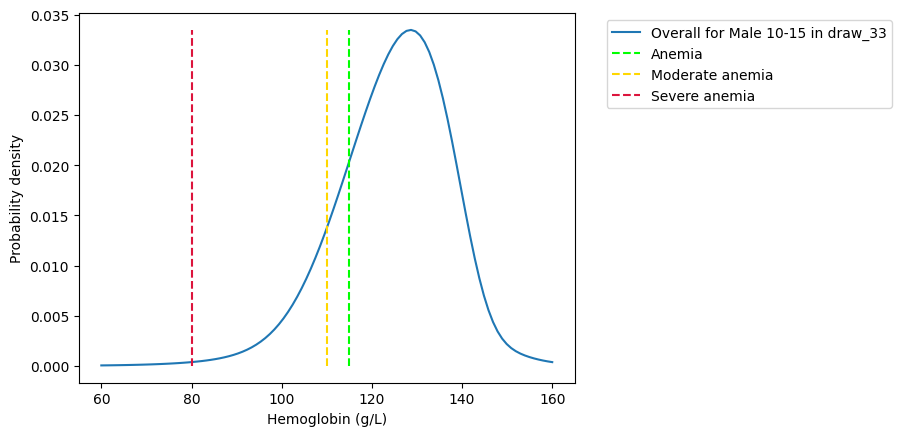

In [91]:
plot_example_distributions({
    "Overall": hemoglobin_distributions_by_age_sex_quintile
})

In [92]:
# Assumption: non-iron-responsive anemias have same distribution of hemoglobin
# as iron-responsive anemias
non_iron_responsive_hemoglobin_distributions = truncate_distributions(
    hemoglobin_distributions_by_age_sex_quintile,
    truncate_max=hgb_info.hgb_upper_mild,
)

In [93]:
# Use even more wiggle room, as the issues in the previous check are "magnified"!
test_pdfs_cdfs_consistency(
    non_iron_responsive_hemoglobin_distributions,
    mean_tolerance=0.01,
    max_tolerance=0.10,
)

count    6.117000e+03
mean     1.521437e-03
std      4.755859e-03
min     -2.010813e-07
25%      1.495930e-05
50%      4.708703e-05
75%      1.471500e-04
max      3.340631e-02
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.076712   0.5      2                draw_369   -2.010813e-07
                            1                draw_87    -1.943551e-07
        2.000000   5.0      1                draw_267   -1.313487e-07
        0.076712   0.5      5                draw_274   -1.088674e-07
                            3                draw_87    -9.472077e-08
                                                             ...     
Female  95.000000  125.0    2                draw_116    3.094317e-02
        90.000000  95.0     4                draw_431    3.122308e-02
                            3                draw_90     3.217975e-02
        95.000000  125.0    1                draw_354    3.265626e-02
                            3                draw_21     3.340631e-02
Length: 6117, dtype: float64

count    6.117000e+03
mean     1.468873e-03
std      4.773387e-03
min     -1.866429e-04
25%     -3.818656e-05
50%      7.572520e-07
75%      8.282943e-05
max      3.341515e-02
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.076712   0.5      1                draw_87    -0.000187
Female  0.076712   0.5      2                draw_141   -0.000179
Male    0.076712   0.5      2                draw_369   -0.000178
        0.500000   1.0      2                draw_255   -0.000178
        0.076712   0.5      3                draw_246   -0.000177
                                                           ...   
Female  95.000000  125.0    2                draw_116    0.030953
        90.000000  95.0     4                draw_431    0.031232
                            3                draw_90     0.032189
        95.000000  125.0    1                draw_354    0.032665
                            3                draw_21     0.033415
Length: 6117, dtype: float64

count    6117.000000
mean       -0.000753
std         0.005609
min        -0.011444
25%        -0.004383
50%        -0.001512
75%        -0.000024
max         0.032233
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    5.0        10.0     5                draw_286   -0.011444
                                             draw_224   -0.011432
                                             draw_379   -0.011265
                                             draw_449   -0.011242
                                             draw_236   -0.011127
                                                           ...   
Female  95.0       125.0    2                draw_116    0.029775
        90.0       95.0     4                draw_431    0.029960
                            3                draw_90     0.030938
        95.0       125.0    1                draw_354    0.031517
                            3                draw_21     0.032233
Length: 6117, dtype: float64

count    6117.000000
mean       -0.003788
std         0.006797
min        -0.019324
25%        -0.006884
50%        -0.004612
75%        -0.002020
max         0.032233
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.0        0.019178    5                draw_89    -0.019324
        25.0       30.000000   5                draw_430   -0.018292
                                                draw_283   -0.018249
                                                draw_126   -0.018172
                                                draw_241   -0.017943
                                                              ...   
Female  95.0       125.000000  2                draw_116    0.029775
        90.0       95.000000   4                draw_431    0.029960
                               3                draw_90     0.030938
        95.0       125.000000  1                draw_354    0.031517
                               3                draw_21     0.032233
Length: 6117, dtype: float64

count    6117.000000
mean       -0.003788
std         0.006797
min        -0.019324
25%        -0.006884
50%        -0.004612
75%        -0.002020
max         0.032233
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.0        0.019178    5                draw_89    -0.019324
        25.0       30.000000   5                draw_430   -0.018292
                                                draw_283   -0.018249
                                                draw_126   -0.018172
                                                draw_241   -0.017943
                                                              ...   
Female  95.0       125.000000  2                draw_116    0.029775
        90.0       95.000000   4                draw_431    0.029960
                               3                draw_90     0.030938
        95.0       125.000000  1                draw_354    0.031517
                               3                draw_21     0.032233
Length: 6117, dtype: float64

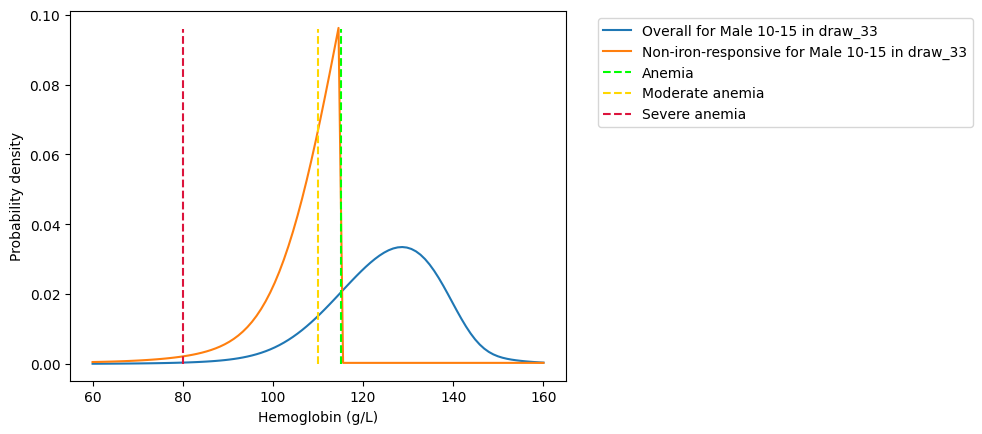

In [94]:
plot_example_distributions({
    "Overall": hemoglobin_distributions_by_age_sex_quintile,
    "Non-iron-responsive": non_iron_responsive_hemoglobin_distributions,
})

In [95]:
gbd_hemoglobin_distributions = distributions_from_mean_sd(gbd_hgb_mean, gbd_hgb_sd.loc[gbd_hgb_mean.index])

In [96]:
gbd_anemia_prevalence = gbd_hemoglobin_distributions.cdfs(thresholds.hgb_upper_mild.reindex(gbd_hgb_mean.index))
gbd_anemia_prevalence

sex     age_start  age_end     draw    
Female  0.0        0.019178    draw_0      0.977267
                               draw_1      0.913643
                               draw_2      0.931276
                               draw_3      0.917822
                               draw_4      0.951764
                                             ...   
Male    95.0       125.000000  draw_495    0.759018
                               draw_496    0.767021
                               draw_497    0.778083
                               draw_498    0.774958
                               draw_499    0.800938
Length: 25000, dtype: float64

In [97]:
non_iron_responsive_anemia_proportion = non_iron_responsive_prevalence / gbd_anemia_prevalence
non_iron_responsive_anemia_proportion

sex     age_start  age_end     draw    
Female  0.0        0.019178    draw_0      0.056189
                               draw_1      0.056089
                               draw_2      0.058032
                               draw_3      0.050788
                               draw_4      0.054701
                                             ...   
Male    95.0       125.000000  draw_495    0.124068
                               draw_496    0.115550
                               draw_497    0.116364
                               draw_498    0.116826
                               draw_499    0.116641
Length: 25000, dtype: float64

In [98]:
non_iron_responsive_anemia_proportion

sex     age_start  age_end     draw    
Female  0.0        0.019178    draw_0      0.056189
                               draw_1      0.056089
                               draw_2      0.058032
                               draw_3      0.050788
                               draw_4      0.054701
                                             ...   
Male    95.0       125.000000  draw_495    0.124068
                               draw_496    0.115550
                               draw_497    0.116364
                               draw_498    0.116826
                               draw_499    0.116641
Length: 25000, dtype: float64

In [99]:
hemoglobin_distributions_by_age_sex_quintile.cdfs(hgb_info.hgb_upper_mild)

sex     age_start  age_end     wealth_quintile  draw    
Female  0.0        0.019178    1                draw_0      0.987992
                                                draw_1      0.945762
                                                draw_2      0.961648
                                                draw_3      0.951058
                                                draw_4      0.973128
                                                              ...   
Male    95.0       125.000000  5                draw_495    0.754600
                                                draw_496    0.762376
                                                draw_497    0.773820
                                                draw_498    0.769831
                                                draw_499    0.795630
Length: 125000, dtype: float64

In [100]:
non_iron_responsive_anemia_prevalence_by_age_sex_quintile = (
    non_iron_responsive_anemia_proportion * hemoglobin_distributions_by_age_sex_quintile.cdfs(hgb_info.hgb_upper_mild)
).reorder_levels(hgb_info.index.names).reindex(hgb_info.index)
non_iron_responsive_anemia_prevalence_by_age_sex_quintile

sex     age_start  age_end     wealth_quintile  draw    
Female  0.0        0.019178    1                draw_0      0.055515
                                                draw_1      0.053046
                                                draw_2      0.055806
                                                draw_3      0.048303
                                                draw_4      0.053231
                                                              ...   
Male    95.0       125.000000  5                draw_495    0.093622
                                                draw_496    0.088092
                                                draw_497    0.090045
                                                draw_498    0.089937
                                                draw_499    0.092803
Length: 125000, dtype: float64

In [101]:
iron_responsive_distributions = delete_from_mixture_distributions(
    hemoglobin_distributions_by_age_sex_quintile,
    non_iron_responsive_hemoglobin_distributions,
    non_iron_responsive_anemia_prevalence_by_age_sex_quintile,
)

In [102]:
test_pdfs_cdfs_consistency(
    iron_responsive_distributions,
    mean_tolerance=0.005,
    max_tolerance=0.05,
)

count    6.117000e+03
mean     1.066132e-03
std      3.318656e-03
min     -1.565668e-07
25%      4.901966e-06
50%      2.399347e-05
75%      8.495202e-05
max      2.314188e-02
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.076712   0.5      2                draw_369   -1.565668e-07
                            1                draw_87    -1.495263e-07
        2.000000   5.0      1                draw_267   -8.479820e-08
        0.076712   0.5      5                draw_274   -7.181328e-08
                            3                draw_87    -6.707115e-08
                                                             ...     
Female  90.000000  95.0     3                draw_90     2.121600e-02
        95.000000  125.0    2                draw_116    2.179526e-02
                            1                draw_116    2.184477e-02
                            3                draw_21     2.296924e-02
                            1                draw_354    2.314188e-02
Length: 6117, dtype: float64

count    6.117000e+03
mean     1.036183e-03
std      3.328838e-03
min     -1.441751e-04
25%     -1.842127e-05
50%      1.355826e-07
75%      4.333902e-05
max      2.314834e-02
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.500000   1.0      2                draw_255   -0.000144
        0.076712   0.5      1                draw_87    -0.000144
                            2                draw_369   -0.000138
        0.500000   1.0      1                draw_416   -0.000136
                            4                draw_490   -0.000133
                                                           ...   
Female  90.000000  95.0     3                draw_90     0.021222
        95.000000  125.0    2                draw_116    0.021802
                            1                draw_116    0.021852
                            3                draw_21     0.022975
                            1                draw_354    0.023148
Length: 6117, dtype: float64

count    6117.000000
mean        0.001254
std         0.003310
min        -0.000187
25%        -0.000001
50%         0.000305
75%         0.000503
max         0.023274
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.019178   0.076712    3                draw_69    -0.000187
Female  0.000000   0.019178    1                draw_93    -0.000162
                                                draw_418   -0.000153
Male    0.019178   0.076712    4                draw_47    -0.000152
                               1                draw_138   -0.000146
                                                              ...   
Female  90.000000  95.000000   3                draw_90     0.021358
        95.000000  125.000000  2                draw_116    0.021930
                               1                draw_116    0.021980
                               3                draw_21     0.023105
                               1                draw_354    0.023274
Length: 6117, dtype: float64

count    6117.000000
mean        0.001427
std         0.003270
min         0.000032
25%         0.000297
50%         0.000488
75%         0.000672
max         0.023275
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.0        0.019178    1                draw_21     0.000032
                                                draw_10     0.000037
Female  0.0        0.019178    1                draw_93     0.000039
Male    0.0        0.019178    1                draw_218    0.000044
Female  0.0        0.019178    1                draw_418    0.000047
                                                              ...   
        90.0       95.000000   3                draw_90     0.021363
        95.0       125.000000  2                draw_116    0.021930
                               1                draw_116    0.021979
                               3                draw_21     0.023108
                               1                draw_354    0.023275
Length: 6117, dtype: float64

count    6117.000000
mean        0.001397
std         0.003275
min         0.000020
25%         0.000283
50%         0.000407
75%         0.000629
max         0.023264
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.0        0.019178    1                draw_21     0.000020
Female  0.0        0.019178    1                draw_93     0.000023
Male    0.0        0.019178    1                draw_10     0.000024
Female  0.0        0.019178    1                draw_418    0.000029
Male    0.0        0.019178    1                draw_218    0.000029
                                                              ...   
Female  90.0       95.000000   3                draw_90     0.021351
        95.0       125.000000  2                draw_116    0.021920
                               1                draw_116    0.021969
                               3                draw_21     0.023096
                               1                draw_354    0.023264
Length: 6117, dtype: float64

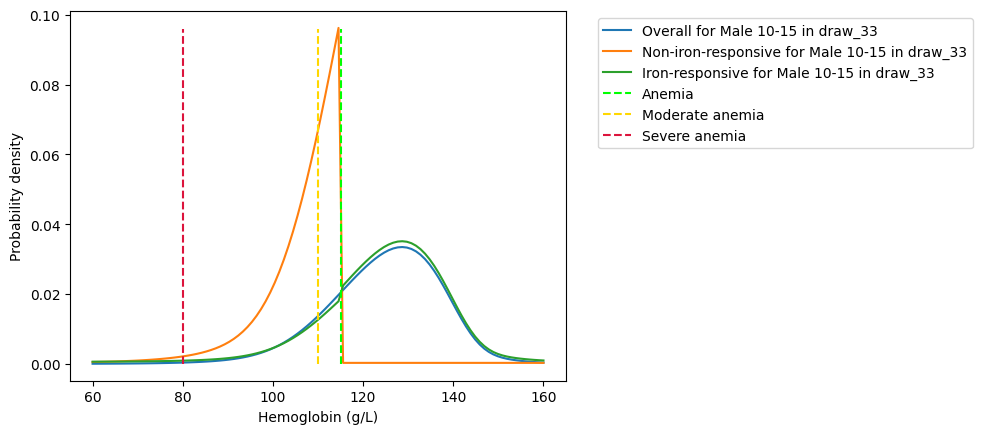

In [103]:
plot_example_distributions({
    "Overall": hemoglobin_distributions_by_age_sex_quintile,
    "Non-iron-responsive": non_iron_responsive_hemoglobin_distributions,
    "Iron-responsive": iron_responsive_distributions,
})

In [104]:
# NOTE: this decomposition, like what we do for wealth quintile above,
# is not exact -- we pretend that these two distributions would mix
# to the overall iron-responsive distribution, but they wouldn't.
# Here, we delete baseline coverage to get the without-fortification distribution.
# Also note that this and the next shift both assume that the hemoglobin effect among
# the responsive is a fixed value without individual-level variation.
iron_responsive_without_fortification_distributions = shift_distributions(
    iron_responsive_distributions,
    - effective_coverage_2021 * hemoglobin_effect_among_responsive.align(hgb_info)[0],
)

In [105]:
test_pdfs_cdfs_consistency(
    iron_responsive_without_fortification_distributions,
    mean_tolerance=0.005,
    max_tolerance=0.05,
)

count    6.117000e+03
mean     1.066132e-03
std      3.318656e-03
min     -1.565668e-07
25%      4.901966e-06
50%      2.399347e-05
75%      8.495202e-05
max      2.314188e-02
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.076712   0.5      2                draw_369   -1.565668e-07
                            1                draw_87    -1.495263e-07
        2.000000   5.0      1                draw_267   -8.479820e-08
        0.076712   0.5      5                draw_274   -7.181328e-08
                            3                draw_87    -6.707115e-08
                                                             ...     
Female  90.000000  95.0     3                draw_90     2.121600e-02
        95.000000  125.0    2                draw_116    2.179526e-02
                            1                draw_116    2.184477e-02
                            3                draw_21     2.296924e-02
                            1                draw_354    2.314188e-02
Length: 6117, dtype: float64

count    6.117000e+03
mean     1.036183e-03
std      3.328838e-03
min     -1.441751e-04
25%     -1.842127e-05
50%      1.355826e-07
75%      4.333902e-05
max      2.314834e-02
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.500000   1.0      2                draw_255   -0.000144
        0.076712   0.5      1                draw_87    -0.000144
                            2                draw_369   -0.000138
        0.500000   1.0      1                draw_416   -0.000136
                            4                draw_490   -0.000133
                                                           ...   
Female  90.000000  95.0     3                draw_90     0.021222
        95.000000  125.0    2                draw_116    0.021802
                            1                draw_116    0.021852
                            3                draw_21     0.022975
                            1                draw_354    0.023148
Length: 6117, dtype: float64

count    6117.000000
mean        0.001254
std         0.003310
min        -0.000187
25%        -0.000001
50%         0.000305
75%         0.000503
max         0.023274
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.019178   0.076712    3                draw_69    -0.000187
Female  0.000000   0.019178    1                draw_93    -0.000162
                                                draw_418   -0.000153
Male    0.019178   0.076712    4                draw_47    -0.000152
                               1                draw_138   -0.000146
                                                              ...   
Female  90.000000  95.000000   3                draw_90     0.021358
        95.000000  125.000000  2                draw_116    0.021930
                               1                draw_116    0.021980
                               3                draw_21     0.023105
                               1                draw_354    0.023274
Length: 6117, dtype: float64

count    6117.000000
mean        0.001427
std         0.003270
min         0.000032
25%         0.000297
50%         0.000488
75%         0.000672
max         0.023275
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.0        0.019178    1                draw_21     0.000032
                                                draw_10     0.000037
Female  0.0        0.019178    1                draw_93     0.000039
Male    0.0        0.019178    1                draw_218    0.000044
Female  0.0        0.019178    1                draw_418    0.000047
                                                              ...   
        90.0       95.000000   3                draw_90     0.021363
        95.0       125.000000  2                draw_116    0.021930
                               1                draw_116    0.021979
                               3                draw_21     0.023108
                               1                draw_354    0.023275
Length: 6117, dtype: float64

count    6117.000000
mean        0.001397
std         0.003275
min         0.000020
25%         0.000283
50%         0.000407
75%         0.000629
max         0.023264
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.0        0.019178    1                draw_21     0.000020
Female  0.0        0.019178    1                draw_93     0.000023
Male    0.0        0.019178    1                draw_10     0.000024
Female  0.0        0.019178    1                draw_418    0.000029
Male    0.0        0.019178    1                draw_218    0.000029
                                                              ...   
Female  90.0       95.000000   3                draw_90     0.021351
        95.0       125.000000  2                draw_116    0.021920
                               1                draw_116    0.021969
                               3                draw_21     0.023096
                               1                draw_354    0.023264
Length: 6117, dtype: float64

In [106]:
iron_responsive_with_fortification_distributions = shift_distributions(
    iron_responsive_without_fortification_distributions,
    hemoglobin_effect_among_responsive.align(hgb_info)[0],
)

In [107]:
test_pdfs_cdfs_consistency(
    iron_responsive_with_fortification_distributions,
    mean_tolerance=0.005,
    max_tolerance=0.05,
)

count    6.117000e+03
mean     1.071715e-03
std      3.333205e-03
min     -7.126538e-08
25%      5.071767e-06
50%      2.458489e-05
75%      8.624833e-05
max      2.322966e-02
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.076712   0.5      2                draw_369   -7.126538e-08
        5.000000   10.0     1                draw_56    -1.409976e-08
                            3                draw_133   -1.352743e-08
                            1                draw_279   -1.346469e-08
                                             draw_300   -1.248274e-08
                                                             ...     
Female  90.000000  95.0     3                draw_90     2.129743e-02
        95.000000  125.0    2                draw_116    2.188378e-02
                            1                draw_116    2.193426e-02
                            3                draw_21     2.305546e-02
                            1                draw_354    2.322966e-02
Length: 6117, dtype: float64

count    6117.000000
mean        0.001047
std         0.003341
min        -0.000122
25%        -0.000009
50%         0.000002
75%         0.000049
max         0.023236
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.5        1.0      1                draw_39    -0.000122
                                             draw_416   -0.000119
                            2                draw_255   -0.000118
Female  0.5        1.0      1                draw_475   -0.000112
Male    0.5        1.0      2                draw_416   -0.000109
                                                           ...   
Female  90.0       95.0     3                draw_90     0.021303
        95.0       125.0    2                draw_116    0.021890
                            1                draw_116    0.021941
                            3                draw_21     0.023062
                            1                draw_354    0.023236
Length: 6117, dtype: float64

count    6117.000000
mean        0.000588
std         0.003440
min        -0.003207
25%        -0.000759
50%        -0.000210
75%        -0.000009
max         0.022958
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    5.0        10.0     1                draw_179   -0.003207
                            5                draw_449   -0.003143
                            1                draw_197   -0.003131
                            2                draw_35    -0.003118
                            4                draw_53    -0.003095
                                                           ...   
Female  90.0       95.0     3                draw_90     0.020996
        95.0       125.0    2                draw_116    0.021617
                            1                draw_116    0.021669
                            3                draw_21     0.022770
                            1                draw_354    0.022958
Length: 6117, dtype: float64

count    6117.000000
mean        0.000373
std         0.003473
min        -0.003919
25%        -0.000825
50%        -0.000619
75%        -0.000367
max         0.022961
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    5.0        10.0     1                draw_179   -0.003919
                                             draw_197   -0.003912
                                             draw_224   -0.003701
                            3                draw_125   -0.003681
                                             draw_37    -0.003590
                                                           ...   
Female  90.0       95.0     3                draw_90     0.021004
        95.0       125.0    2                draw_116    0.021621
                            1                draw_116    0.021671
                            3                draw_21     0.022776
                            1                draw_354    0.022961
Length: 6117, dtype: float64

count    6117.000000
mean        0.000331
std         0.003478
min        -0.003919
25%        -0.000842
50%        -0.000669
75%        -0.000417
max         0.022950
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    5.0        10.0     1                draw_179   -0.003919
                                             draw_197   -0.003912
                                             draw_224   -0.003701
                            3                draw_125   -0.003681
                                             draw_37    -0.003590
                                                           ...   
Female  90.0       95.0     3                draw_90     0.020991
        95.0       125.0    2                draw_116    0.021609
                            1                draw_116    0.021660
                            3                draw_21     0.022764
                            1                draw_354    0.022950
Length: 6117, dtype: float64

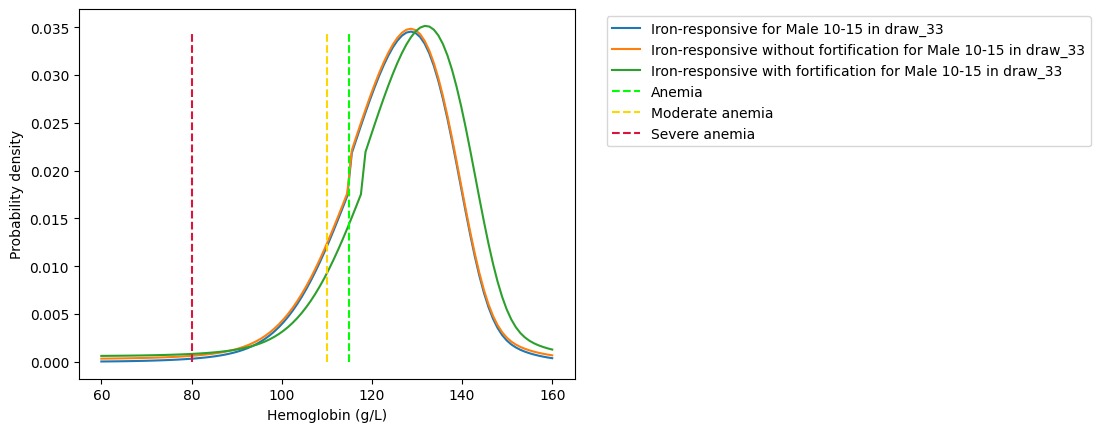

In [108]:
plot_example_distributions({
    "Iron-responsive": iron_responsive_distributions,
    "Iron-responsive without fortification": iron_responsive_without_fortification_distributions,
    "Iron-responsive with fortification": iron_responsive_with_fortification_distributions,
})

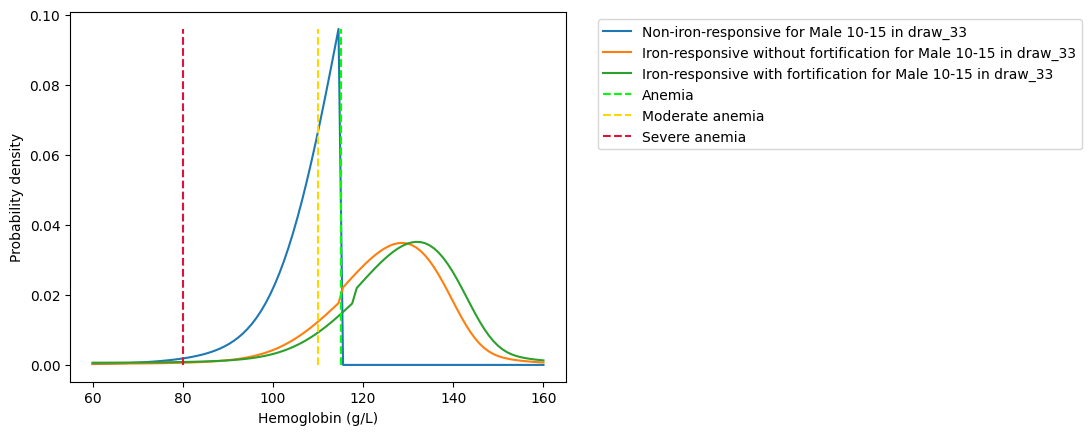

In [109]:
plot_example_distributions({
    "Non-iron-responsive": non_iron_responsive_hemoglobin_distributions,
    "Iron-responsive without fortification": iron_responsive_without_fortification_distributions,
    "Iron-responsive with fortification": iron_responsive_with_fortification_distributions,
})

In [110]:
zero_fort_scenario_distributions = mix_distributions([
    (
        non_iron_responsive_hemoglobin_distributions,
        non_iron_responsive_anemia_prevalence_by_age_sex_quintile,
    ),
    (
        iron_responsive_without_fortification_distributions,
        1 - non_iron_responsive_anemia_prevalence_by_age_sex_quintile,
    ),
])

In [111]:
test_pdfs_cdfs_consistency(
    zero_fort_scenario_distributions,
    mean_tolerance=0.005,
    max_tolerance=0.05,
)

count    6.117000e+03
mean     1.107607e-03
std      3.449037e-03
min     -1.596265e-07
25%      5.483605e-06
50%      2.538685e-05
75%      8.847887e-05
max      2.398498e-02
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.076712   0.5      2                draw_369   -1.596265e-07
                            1                draw_87    -1.528538e-07
        2.000000   5.0      1                draw_267   -8.805745e-08
        0.076712   0.5      5                draw_274   -7.404795e-08
                            3                draw_87    -6.897131e-08
                                                             ...     
Female  90.000000  95.0     3                draw_90     2.220038e-02
        95.000000  125.0    2                draw_116    2.259621e-02
                            1                draw_116    2.261911e-02
                            3                draw_21     2.390457e-02
                            1                draw_354    2.398498e-02
Length: 6117, dtype: float64

count    6.117000e+03
mean     1.076302e-03
std      3.459672e-03
min     -1.467885e-04
25%     -1.955933e-05
50%      1.566505e-07
75%      4.645420e-05
max      2.399167e-02
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.076712   0.5      1                draw_87    -0.000147
        0.500000   1.0      2                draw_255   -0.000146
        0.076712   0.5      2                draw_369   -0.000141
        0.500000   1.0      1                draw_416   -0.000138
                            4                draw_490   -0.000135
                                                           ...   
Female  90.000000  95.0     3                draw_90     0.022206
        95.000000  125.0    2                draw_116    0.022603
                            1                draw_116    0.022626
                            3                draw_21     0.023911
                            1                draw_354    0.023992
Length: 6117, dtype: float64

count    6117.000000
mean        0.001140
std         0.003449
min        -0.000197
25%        -0.000017
50%         0.000088
75%         0.000196
max         0.024005
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.019178   0.076712    3                draw_69    -0.000197
        15.000000  20.000000   1                draw_344   -0.000164
Female  0.000000   0.019178    1                draw_93    -0.000162
Male    0.019178   0.076712    4                draw_47    -0.000160
                               1                draw_138   -0.000153
                                                              ...   
Female  90.000000  95.000000   3                draw_90     0.022218
        95.000000  125.000000  2                draw_116    0.022617
                               1                draw_116    0.022640
                               3                draw_21     0.023923
                               1                draw_354    0.024005
Length: 6117, dtype: float64

count    6.117000e+03
mean     1.138853e-03
std      3.446606e-03
min      2.295719e-12
25%      2.472045e-05
50%      7.147154e-05
75%      1.383371e-04
max      2.400500e-02
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    5.0        10.0     1                draw_271    2.295719e-12
                            2                draw_441    6.324163e-12
                            3                draw_266    1.970202e-11
                            5                draw_224    3.257850e-11
                            3                draw_125    3.576273e-11
                                                             ...     
Female  90.0       95.0     3                draw_90     2.222276e-02
        95.0       125.0    2                draw_116    2.261695e-02
                            1                draw_116    2.263936e-02
                            3                draw_21     2.392542e-02
                            1                draw_354    2.400500e-02
Length: 6117, dtype: float64

count    6.117000e+03
mean     1.110258e-03
std      3.452382e-03
min     -1.214584e-13
25%      6.247293e-06
50%      2.662870e-05
75%      9.044509e-05
max      2.399575e-02
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.0        0.019178    1                draw_10    -1.214584e-13
                               2                draw_140   -8.915091e-14
                               5                draw_247   -8.004708e-14
                               2                draw_3     -6.483702e-14
                               4                draw_449   -6.461498e-14
                                                                ...     
Female  90.0       95.000000   3                draw_90     2.221153e-02
        95.0       125.000000  2                draw_116    2.260748e-02
                               1                draw_116    2.263045e-02
                               3                draw_21     2.391525e-02
                               1                draw_354    2.399575e-02
Length: 6117, dtype: float64

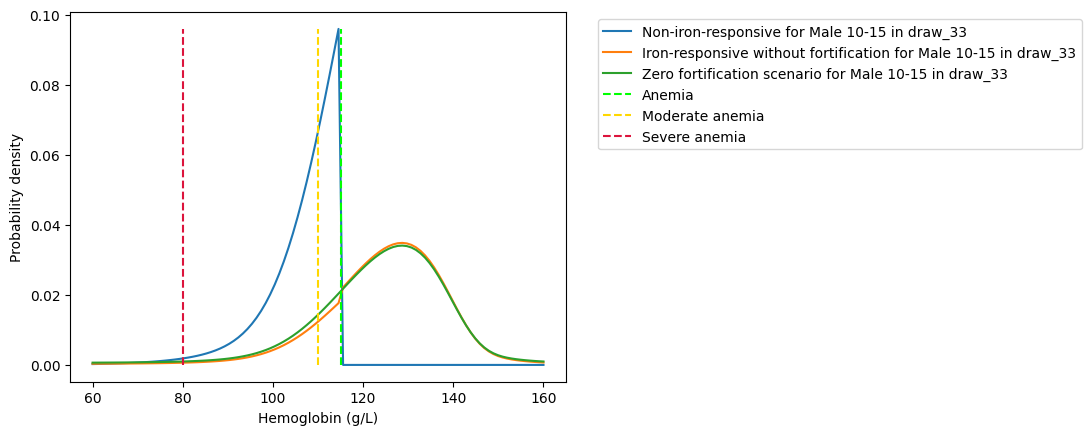

In [112]:
plot_example_distributions({
    "Non-iron-responsive": non_iron_responsive_hemoglobin_distributions,
    "Iron-responsive without fortification": iron_responsive_without_fortification_distributions,
    "Zero fortification scenario": zero_fort_scenario_distributions,
})

In [113]:
baseline_scenario_distributions = mix_distributions([
    (
        non_iron_responsive_hemoglobin_distributions,
        non_iron_responsive_anemia_prevalence_by_age_sex_quintile,
    ),
    (
        iron_responsive_without_fortification_distributions,
        (1 - non_iron_responsive_anemia_prevalence_by_age_sex_quintile) * (1 - effective_coverage_baseline),
    ),
    (
        iron_responsive_with_fortification_distributions,
        (1 - non_iron_responsive_anemia_prevalence_by_age_sex_quintile) * effective_coverage_baseline,
    ),
])

In [114]:
test_pdfs_cdfs_consistency(
    baseline_scenario_distributions,
    mean_tolerance=0.005,
    max_tolerance=0.05,
)

count    6.117000e+03
mean     1.109171e-03
std      3.453253e-03
min     -1.352959e-07
25%      5.520529e-06
50%      2.550371e-05
75%      8.881384e-05
max      2.401585e-02
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.076712   0.5      2                draw_369   -1.352959e-07
                            1                draw_87    -1.124005e-07
                            5                draw_274   -5.875769e-08
        2.000000   5.0      1                draw_267   -5.786654e-08
        5.000000   10.0     1                draw_116   -3.407622e-08
                                                             ...     
Female  90.000000  95.0     3                draw_90     2.222533e-02
        95.000000  125.0    2                draw_116    2.262633e-02
                            1                draw_116    2.265058e-02
                            3                draw_21     2.393100e-02
                            1                draw_354    2.401585e-02
Length: 6117, dtype: float64

count    6.117000e+03
mean     1.079143e-03
std      3.463364e-03
min     -1.387662e-04
25%     -1.720814e-05
50%      6.422033e-07
75%      4.767824e-05
max      2.402253e-02
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.500000   1.0      2                draw_255   -0.000139
                            1                draw_416   -0.000133
        0.076712   0.5      1                draw_87    -0.000133
        0.500000   1.0      1                draw_39    -0.000130
                            4                draw_490   -0.000130
                                                           ...   
Female  90.000000  95.0     3                draw_90     0.022231
        95.000000  125.0    2                draw_116    0.022633
                            1                draw_116    0.022658
                            3                draw_21     0.023937
                            1                draw_354    0.024023
Length: 6117, dtype: float64

count    6117.000000
mean        0.000958
std         0.003479
min        -0.001271
25%        -0.000202
50%        -0.000064
75%         0.000038
max         0.023893
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    10.0       15.0     1                draw_337   -0.001271
        5.0        10.0     1                draw_224   -0.001215
                                             draw_197   -0.001214
                                             draw_179   -0.001178
                                             draw_271   -0.001164
                                                           ...   
Female  90.0       95.0     3                draw_90     0.022107
        95.0       125.0    2                draw_116    0.022510
                            1                draw_116    0.022531
                            3                draw_21     0.023820
                            1                draw_354    0.023893
Length: 6117, dtype: float64

count    6117.000000
mean        0.000851
std         0.003500
min        -0.001745
25%        -0.000318
50%        -0.000184
75%        -0.000018
max         0.023895
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    5.0        10.0     1                draw_179   -0.001745
                                             draw_197   -0.001729
                                             draw_224   -0.001648
                                             draw_271   -0.001621
                                             draw_1     -0.001593
                                                           ...   
Female  90.0       95.0     3                draw_90     0.022113
        95.0       125.0    2                draw_116    0.022512
                            1                draw_116    0.022531
                            3                draw_21     0.023824
                            1                draw_354    0.023895
Length: 6117, dtype: float64

count    6117.000000
mean        0.000820
std         0.003506
min        -0.001745
25%        -0.000351
50%        -0.000209
75%        -0.000075
max         0.023885
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    5.0        10.0     1                draw_179   -0.001745
                                             draw_197   -0.001729
                                             draw_224   -0.001648
                                             draw_271   -0.001621
                                             draw_1     -0.001593
                                                           ...   
Female  90.0       95.0     3                draw_90     0.022101
        95.0       125.0    2                draw_116    0.022502
                            1                draw_116    0.022522
                            3                draw_21     0.023813
                            1                draw_354    0.023885
Length: 6117, dtype: float64

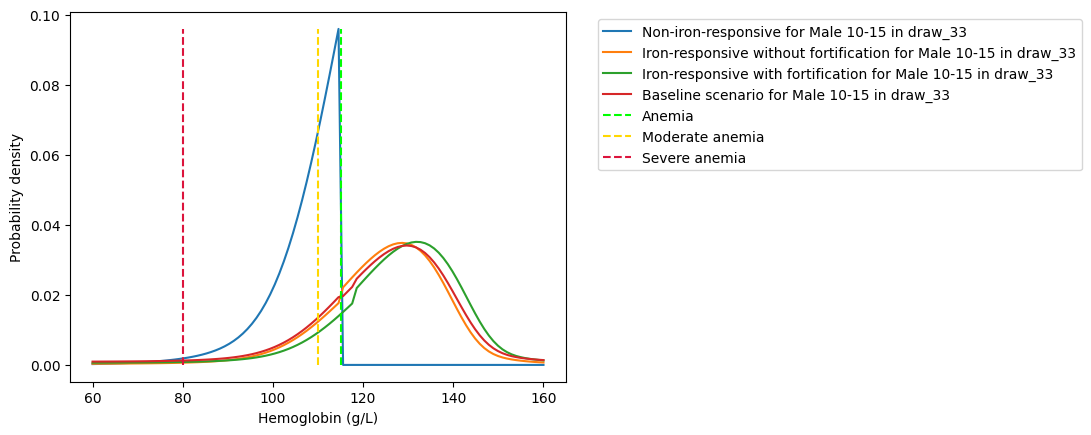

In [115]:
plot_example_distributions({
    "Non-iron-responsive": non_iron_responsive_hemoglobin_distributions,
    "Iron-responsive without fortification": iron_responsive_without_fortification_distributions,
    "Iron-responsive with fortification": iron_responsive_with_fortification_distributions,
    "Baseline scenario": baseline_scenario_distributions,
})

In [116]:
intervention_scenario_distributions = {}

for intervention_scenario in intervention_scenarios:
    effective_coverage_for_scenario = effective_coverage_intervention[
        effective_coverage_intervention.index.get_level_values('scenario') == intervention_scenario
    ].droplevel('scenario').reindex(hgb_info.index)
    intervention_scenario_distributions[intervention_scenario] = mix_distributions([
        (
            non_iron_responsive_hemoglobin_distributions,
            non_iron_responsive_anemia_prevalence_by_age_sex_quintile,
        ),
        (
            iron_responsive_without_fortification_distributions,
            (1 - non_iron_responsive_anemia_prevalence_by_age_sex_quintile) * (1 - effective_coverage_for_scenario),
        ),
        (
            iron_responsive_with_fortification_distributions,
            (1 - non_iron_responsive_anemia_prevalence_by_age_sex_quintile) * effective_coverage_for_scenario,
        ),
    ])


In [117]:
for _, dists in intervention_scenario_distributions.items():
    test_pdfs_cdfs_consistency(
        dists,
        mean_tolerance=0.005,
        max_tolerance=0.05,
    )

count    6.117000e+03
mean     1.109171e-03
std      3.453253e-03
min     -1.352959e-07
25%      5.520529e-06
50%      2.550371e-05
75%      8.881384e-05
max      2.401585e-02
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.076712   0.5      2                draw_369   -1.352959e-07
                            1                draw_87    -1.124005e-07
                            5                draw_274   -5.875769e-08
        2.000000   5.0      1                draw_267   -5.786654e-08
        5.000000   10.0     1                draw_116   -3.407622e-08
                                                             ...     
Female  90.000000  95.0     3                draw_90     2.222533e-02
        95.000000  125.0    2                draw_116    2.262633e-02
                            1                draw_116    2.265058e-02
                            3                draw_21     2.393100e-02
                            1                draw_354    2.401585e-02
Length: 6117, dtype: float64

count    6.117000e+03
mean     1.079143e-03
std      3.463364e-03
min     -1.387662e-04
25%     -1.720814e-05
50%      6.422033e-07
75%      4.767824e-05
max      2.402253e-02
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.500000   1.0      2                draw_255   -0.000139
                            1                draw_416   -0.000133
        0.076712   0.5      1                draw_87    -0.000133
        0.500000   1.0      1                draw_39    -0.000130
                            4                draw_490   -0.000130
                                                           ...   
Female  90.000000  95.0     3                draw_90     0.022231
        95.000000  125.0    2                draw_116    0.022633
                            1                draw_116    0.022658
                            3                draw_21     0.023937
                            1                draw_354    0.024023
Length: 6117, dtype: float64

count    6117.000000
mean        0.000958
std         0.003479
min        -0.001271
25%        -0.000202
50%        -0.000064
75%         0.000038
max         0.023893
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    10.0       15.0     1                draw_337   -0.001271
        5.0        10.0     1                draw_224   -0.001215
                                             draw_197   -0.001214
                                             draw_179   -0.001178
                                             draw_271   -0.001164
                                                           ...   
Female  90.0       95.0     3                draw_90     0.022107
        95.0       125.0    2                draw_116    0.022510
                            1                draw_116    0.022531
                            3                draw_21     0.023820
                            1                draw_354    0.023893
Length: 6117, dtype: float64

count    6117.000000
mean        0.000851
std         0.003500
min        -0.001745
25%        -0.000318
50%        -0.000184
75%        -0.000018
max         0.023895
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    5.0        10.0     1                draw_179   -0.001745
                                             draw_197   -0.001729
                                             draw_224   -0.001648
                                             draw_271   -0.001621
                                             draw_1     -0.001593
                                                           ...   
Female  90.0       95.0     3                draw_90     0.022113
        95.0       125.0    2                draw_116    0.022512
                            1                draw_116    0.022531
                            3                draw_21     0.023824
                            1                draw_354    0.023895
Length: 6117, dtype: float64

count    6117.000000
mean        0.000820
std         0.003506
min        -0.001745
25%        -0.000351
50%        -0.000209
75%        -0.000075
max         0.023885
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    5.0        10.0     1                draw_179   -0.001745
                                             draw_197   -0.001729
                                             draw_224   -0.001648
                                             draw_271   -0.001621
                                             draw_1     -0.001593
                                                           ...   
Female  90.0       95.0     3                draw_90     0.022101
        95.0       125.0    2                draw_116    0.022502
                            1                draw_116    0.022522
                            3                draw_21     0.023813
                            1                draw_354    0.023885
Length: 6117, dtype: float64

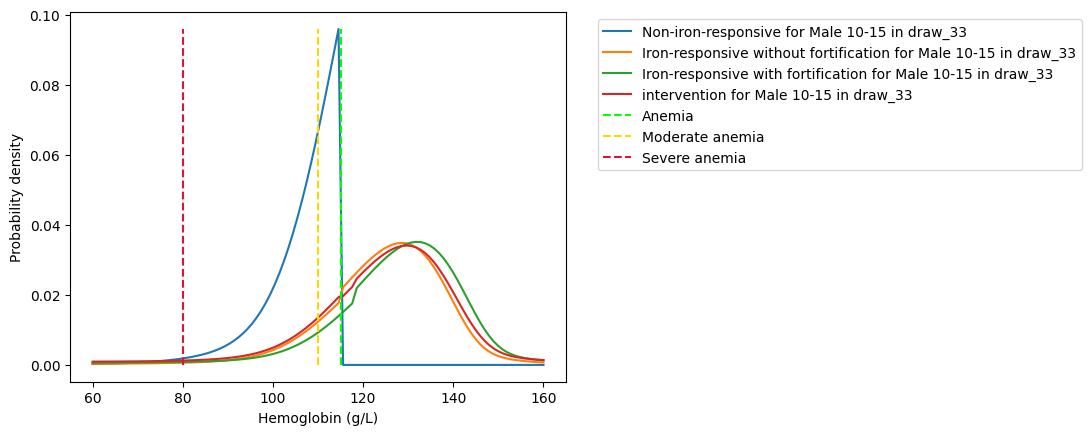

In [118]:
for intervention_scenario in intervention_scenarios:
    plot_example_distributions({
        "Non-iron-responsive": non_iron_responsive_hemoglobin_distributions,
        "Iron-responsive without fortification": iron_responsive_without_fortification_distributions,
        "Iron-responsive with fortification": iron_responsive_with_fortification_distributions,
        intervention_scenario: intervention_scenario_distributions[intervention_scenario],
    })
    plt.show()

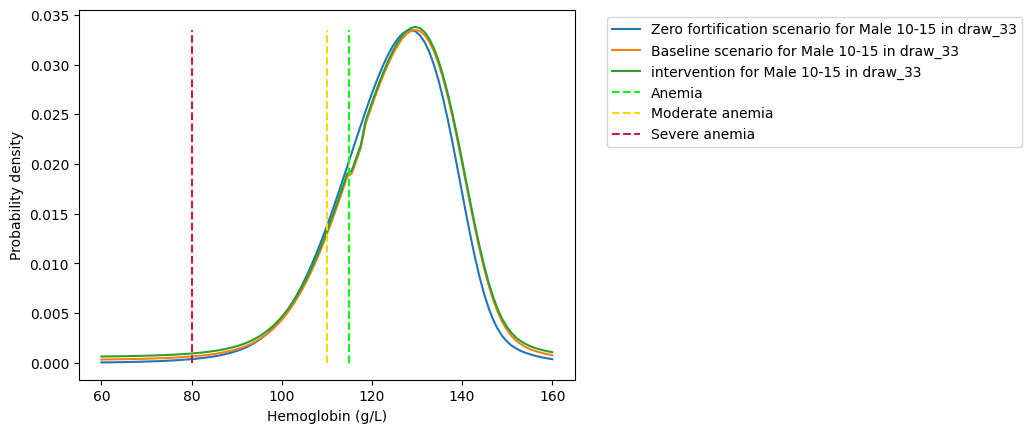

In [119]:
plot_example_distributions({
    "Zero fortification scenario": zero_fort_scenario_distributions,
    "Baseline scenario": baseline_scenario_distributions,
    **intervention_scenario_distributions,
})

In [120]:
def anemia_by_severity_from_distributions(distributions: Distributions):
    result = pd.DataFrame(index=distributions.data_index)
    assert result.index.equals(hgb_info.index)

    result["severe"] = distributions.cdfs(hgb_info.hgb_upper_severe.copy()) - distributions.cdfs(
        hgb_info.hgb_lower_severe.copy()
    )
    result["moderate"] = distributions.cdfs(hgb_info.hgb_upper_moderate.copy()) - result["severe"]
    result["mild"] = (
        distributions.cdfs(hgb_info.hgb_upper_mild.copy())
        - result["moderate"]
        - result["severe"]
    )
    result["anemic"] = result["mild"] + result["moderate"] + result["severe"]

    assert (result >= 0).all().all()
    assert (result <= 1).all().all()
    return result

In [121]:
zero_fort_scenario_anemia_by_severity = anemia_by_severity_from_distributions(zero_fort_scenario_distributions)
zero_fort_scenario_anemia_by_severity

severe  moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    0.003702  0.708900   
                                            draw_1    0.014031  0.625490   
                                            draw_2    0.005898  0.605890   
                                            draw_3    0.008843  0.607235   
                                            draw_4    0.007315  0.663041   
...                                                        ...       ...   
Male   95.0      125.000000 5               draw_495  0.239764  0.303811   
                                            draw_496  0.230058  0.312357   
                                            draw_497  0.232637  0.318704   
                                            draw_498  0.214673  0.322711   
                                            draw_499  0.195046  0.346445   

                                                          mild    anemic  
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0    0.275391  0.987992  
                                            draw_1    0.306242  0.945762  
                                            draw_2    0.349860  0.961648  
                                            draw_3    0.334980  0.951058  
                                            draw_4    0.302771  0.973128  
...                                                        ...       ...  
Male   95.0      125.000000 5               draw_495  0.211025  0.754600  
                                            draw_496  0.219961  0.762376  
                                            draw_497  0.222479  0.773820  
                                            draw_498  0.232447  0.769831  
                                            draw_499  0.254139  0.795630  

[125000 rows x 4 columns]

In [122]:
baseline_scenario_anemia_by_severity = anemia_by_severity_from_distributions(baseline_scenario_distributions)
baseline_scenario_anemia_by_severity

severe  moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    0.003362  0.672953   
                                            draw_1    0.012965  0.600288   
                                            draw_2    0.005416  0.575227   
                                            draw_3    0.008148  0.579096   
                                            draw_4    0.006710  0.632460   
...                                                        ...       ...   
Male   95.0      125.000000 5               draw_495  0.237631  0.301288   
                                            draw_496  0.227672  0.309839   
                                            draw_497  0.230135  0.316206   
                                            draw_498  0.212049  0.320164   
                                            draw_499  0.192050  0.343702   

                                                          mild    anemic  
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0    0.307638  0.983952  
                                            draw_1    0.321070  0.934323  
                                            draw_2    0.370092  0.950735  
                                            draw_3    0.351881  0.939125  
                                            draw_4    0.326107  0.965278  
...                                                        ...       ...  
Male   95.0      125.000000 5               draw_495  0.211374  0.750293  
                                            draw_496  0.220367  0.757878  
                                            draw_497  0.222978  0.769319  
                                            draw_498  0.232907  0.765120  
                                            draw_499  0.254855  0.790607  

[125000 rows x 4 columns]

In [123]:
intervention_scenarios_anemia_by_severity = {}

for scenario, distributions in intervention_scenario_distributions.items():
    anemia_by_severity = anemia_by_severity_from_distributions(distributions)
    print(scenario)
    display(anemia_by_severity)
    intervention_scenarios_anemia_by_severity[scenario] = anemia_by_severity

intervention


severe  moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    0.003362  0.672953   
                                            draw_1    0.012965  0.600288   
                                            draw_2    0.005416  0.575227   
                                            draw_3    0.008148  0.579096   
                                            draw_4    0.006710  0.632460   
...                                                        ...       ...   
Male   95.0      125.000000 5               draw_495  0.237631  0.301288   
                                            draw_496  0.227672  0.309839   
                                            draw_497  0.230135  0.316206   
                                            draw_498  0.212049  0.320164   
                                            draw_499  0.192050  0.343702   

                                                          mild    anemic  
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0    0.307638  0.983952  
                                            draw_1    0.321070  0.934323  
                                            draw_2    0.370092  0.950735  
                                            draw_3    0.351881  0.939125  
                                            draw_4    0.326107  0.965278  
...                                                        ...       ...  
Male   95.0      125.000000 5               draw_495  0.211374  0.750293  
                                            draw_496  0.220367  0.757878  
                                            draw_497  0.222978  0.769319  
                                            draw_498  0.232907  0.765120  
                                            draw_499  0.254855  0.790607  

[125000 rows x 4 columns]

In [124]:
# Transform the intervention scenarios back from a dictionary to the scenario being a level
# in the MultiIndex, which is easier to work with now that we are out of function/distribution space.
intervention_scenarios_anemia_by_severity = pd.concat([
    anemia_by_severity.assign(scenario=scenario).set_index("scenario", append=True)
    for scenario, anemia_by_severity in intervention_scenarios_anemia_by_severity.items()
])
intervention_scenarios_anemia_by_severity

severe  \
sex    age_start age_end    wealth_quintile draw     scenario                 
Female 0.0       0.019178   1               draw_0   intervention  0.003362   
                                            draw_1   intervention  0.012965   
                                            draw_2   intervention  0.005416   
                                            draw_3   intervention  0.008148   
                                            draw_4   intervention  0.006710   
...                                                                     ...   
Male   95.0      125.000000 5               draw_495 intervention  0.237631   
                                            draw_496 intervention  0.227672   
                                            draw_497 intervention  0.230135   
                                            draw_498 intervention  0.212049   
                                            draw_499 intervention  0.192050   

                                                                   moderate  \
sex    age_start age_end    wealth_quintile draw     scenario                 
Female 0.0       0.019178   1               draw_0   intervention  0.672953   
                                            draw_1   intervention  0.600288   
                                            draw_2   intervention  0.575227   
                                            draw_3   intervention  0.579096   
                                            draw_4   intervention  0.632460   
...                                                                     ...   
Male   95.0      125.000000 5               draw_495 intervention  0.301288   
                                            draw_496 intervention  0.309839   
                                            draw_497 intervention  0.316206   
                                            draw_498 intervention  0.320164   
                                            draw_499 intervention  0.343702   

                                                                       mild  \
sex    age_start age_end    wealth_quintile draw     scenario                 
Female 0.0       0.019178   1               draw_0   intervention  0.307638   
                                            draw_1   intervention  0.321070   
                                            draw_2   intervention  0.370092   
                                            draw_3   intervention  0.351881   
                                            draw_4   intervention  0.326107   
...                                                                     ...   
Male   95.0      125.000000 5               draw_495 intervention  0.211374   
                                            draw_496 intervention  0.220367   
                                            draw_497 intervention  0.222978   
                                            draw_498 intervention  0.232907   
                                            draw_499 intervention  0.254855   

                                                                     anemic  
sex    age_start age_end    wealth_quintile draw     scenario                
Female 0.0       0.019178   1               draw_0   intervention  0.983952  
                                            draw_1   intervention  0.934323  
                                            draw_2   intervention  0.950735  
                                            draw_3   intervention  0.939125  
                                            draw_4   intervention  0.965278  
...                                                                     ...  
Male   95.0      125.000000 5               draw_495 intervention  0.750293  
                                            draw_496 intervention  0.757878  
                                            draw_497 intervention  0.769319  
                                            draw_498 intervention  0.765120  
                                            draw_

In [125]:
zero_fort_scenario_anemia_by_severity - baseline_scenario_anemia_by_severity

severe  moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    0.000340  0.035947   
                                            draw_1    0.001066  0.025202   
                                            draw_2    0.000482  0.030664   
                                            draw_3    0.000695  0.028138   
                                            draw_4    0.000605  0.030581   
...                                                        ...       ...   
Male   95.0      125.000000 5               draw_495  0.002133  0.002523   
                                            draw_496  0.002386  0.002518   
                                            draw_497  0.002502  0.002498   
                                            draw_498  0.002624  0.002547   
                                            draw_499  0.002996  0.002743   

                                                          mild    anemic  
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0   -0.032247  0.004040  
                                            draw_1   -0.014829  0.011439  
                                            draw_2   -0.020232  0.010913  
                                            draw_3   -0.016901  0.011932  
                                            draw_4   -0.023336  0.007850  
...                                                        ...       ...  
Male   95.0      125.000000 5               draw_495 -0.000349  0.004307  
                                            draw_496 -0.000406  0.004498  
                                            draw_497 -0.000499  0.004501  
                                            draw_498 -0.000460  0.004712  
                                            draw_499 -0.000716  0.005023  

[125000 rows x 4 columns]

In [126]:
baseline_scenario_anemia_by_severity - intervention_scenarios_anemia_by_severity

severe  \
sex    age_start age_end    wealth_quintile draw     scenario               
Female 0.0       0.019178   1               draw_0   intervention     0.0   
                                            draw_1   intervention     0.0   
                                            draw_2   intervention     0.0   
                                            draw_3   intervention     0.0   
                                            draw_4   intervention     0.0   
...                                                                   ...   
Male   95.0      125.000000 5               draw_495 intervention     0.0   
                                            draw_496 intervention     0.0   
                                            draw_497 intervention     0.0   
                                            draw_498 intervention     0.0   
                                            draw_499 intervention     0.0   

                                                                   moderate  \
sex    age_start age_end    wealth_quintile draw     scenario                 
Female 0.0       0.019178   1               draw_0   intervention       0.0   
                                            draw_1   intervention       0.0   
                                            draw_2   intervention       0.0   
                                            draw_3   intervention       0.0   
                                            draw_4   intervention       0.0   
...                                                                     ...   
Male   95.0      125.000000 5               draw_495 intervention       0.0   
                                            draw_496 intervention       0.0   
                                            draw_497 intervention       0.0   
                                            draw_498 intervention       0.0   
                                            draw_499 intervention       0.0   

                                                                   mild  \
sex    age_start age_end    wealth_quintile draw     scenario             
Female 0.0       0.019178   1               draw_0   intervention   0.0   
                                            draw_1   intervention   0.0   
                                            draw_2   intervention   0.0   
                                            draw_3   intervention   0.0   
                                            draw_4   intervention   0.0   
...                                                                 ...   
Male   95.0      125.000000 5               draw_495 intervention   0.0   
                                            draw_496 intervention   0.0   
                                            draw_497 intervention   0.0   
                                            draw_498 intervention   0.0   
                                            draw_499 intervention   0.0   

                                                                   anemic  
sex    age_start age_end    wealth_quintile draw     scenario              
Female 0.0       0.019178   1               draw_0   intervention     0.0  
                                            draw_1   intervention     0.0  
                                            draw_2   intervention     0.0  
                                            draw_3   intervention     0.0  
                                            draw_4   intervention     0.0  
...                                                                   ...  
Male   95.0      125.000000 5               draw_495 intervention     0.0  
                                            draw_496 intervention     0.0  
                                            draw_497 intervention     0.0  
                                            draw_498 intervention     0.0  
                                            draw_499 intervention     0.0  

[125000 rows x 4 columns]

<Axes: >

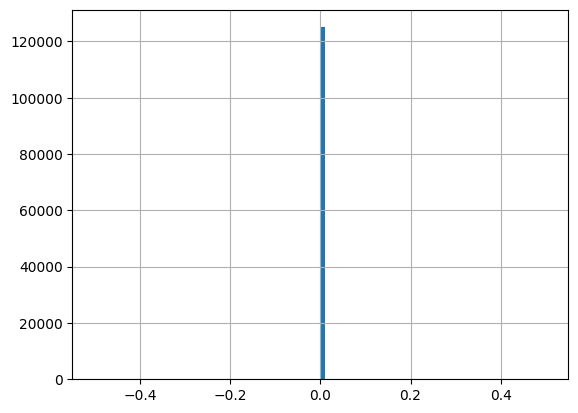

In [127]:
# We can see that in very rare cases, likely due to numerical instability, we get a negative impact
(baseline_scenario_anemia_by_severity - intervention_scenarios_anemia_by_severity).anemic.hist(bins=100)

In [128]:
def anemia_by_severity_to_yld_rates(anemia_by_severity):
    disability_weights = pd.read_hdf(
        "/mnt/team/simulation_science/costeffectiveness/auxiliary_data/GBD_2021/02_processed_data/disability_weight/sequela/all/all.hdf"
    )
    disability_weights = (
        disability_weights[
            disability_weights.healthstate.isin(
                ["anemia_mild", "anemia_mod", "anemia_sev"]
            )
        ]
        .set_index("healthstate")
        .filter(like="draw_")
    )
    disability_weights.columns.name = "draw"
    disability_weights = (
        disability_weights.stack().rename("disability_weight").reset_index()
    )
    display(disability_weights)

    orig_index = anemia_by_severity.index
    anemia_by_severity = (
        anemia_by_severity.reset_index()
        .merge(
            disability_weights[disability_weights.healthstate == "anemia_mild"][
                ["draw", "disability_weight"]
            ].rename(columns={"disability_weight": "mild_dw"}),
            validate="m:1",
        )
        .merge(
            disability_weights[disability_weights.healthstate == "anemia_mod"][
                ["draw", "disability_weight"]
            ].rename(columns={"disability_weight": "moderate_dw"}),
            validate="m:1",
        )
        .merge(
            disability_weights[disability_weights.healthstate == "anemia_sev"][
                ["draw", "disability_weight"]
            ].rename(columns={"disability_weight": "severe_dw"}),
            validate="m:1",
        )
    )

    anemia_by_severity["mild_yld_rate"] = anemia_by_severity.mild * anemia_by_severity.mild_dw
    anemia_by_severity["moderate_yld_rate"] = anemia_by_severity.moderate * anemia_by_severity.moderate_dw
    anemia_by_severity["severe_yld_rate"] = anemia_by_severity.severe * anemia_by_severity.severe_dw
    anemia_by_severity["anemic_yld_rate"] = (
        anemia_by_severity["mild_yld_rate"]
        + anemia_by_severity["moderate_yld_rate"]
        + anemia_by_severity["severe_yld_rate"]
    )

    return anemia_by_severity.set_index(orig_index.names).filter(like="yld_rate")

In [129]:
zero_fort_scenario_anemia_yld_rates = anemia_by_severity_to_yld_rates(zero_fort_scenario_anemia_by_severity)
zero_fort_scenario_anemia_yld_rates

,healthstate,draw,disability_weight
0,anemia_mild,draw_0,0.002420
1,anemia_mild,draw_1,0.003172
2,anemia_mild,draw_2,0.002644
3,anemia_mild,draw_3,0.003085
4,anemia_mild,draw_4,0.001845
...,...,...,...
2995,anemia_sev,draw_995,0.174969
2996,anemia_sev,draw_996,0.086798
2997,anemia_sev,draw_997,0.131996
2998,anemia_sev,draw_998,0.124427


mild_yld_rate  \
sex    age_start age_end    wealth_quintile draw                      
Female 0.0       0.019178   1               draw_0         0.000667   
                            2               draw_0         0.000847   
                            3               draw_0         0.000866   
                            4               draw_0         0.001002   
                            5               draw_0         0.001121   
...                                                             ...   
Male   95.0      125.000000 1               draw_499       0.000755   
                            2               draw_499       0.000757   
                            3               draw_499       0.000749   
                            4               draw_499       0.000766   
                            5               draw_499       0.000804   

                                                      moderate_yld_rate  \
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0             0.042038   
                            2               draw_0             0.037203   
                            3               draw_0             0.036503   
                            4               draw_0             0.032433   
                            5               draw_0             0.028919   
...                                                                 ...   
Male   95.0      125.000000 1               draw_499           0.014737   
                            2               draw_499           0.014474   
                            3               draw_499           0.014233   
                            4               draw_499           0.014297   
                            5               draw_499           0.014594   

                                                      severe_yld_rate  \
sex    age_start age_end    wealth_quintile draw                        
Female 0.0       0.019178   1               draw_0           0.000736   
                            2               draw_0           0.000580   
                            3               draw_0           0.000645   
                            4               draw_0           0.000523   
                            5               draw_0           0.000358   
...                                                               ...   
Male   95.0      125.000000 1               draw_499         0.024377   
                            2               draw_499         0.023642   
                            3               draw_499         0.023664   
                            4               draw_499         0.022640   
                            5               draw_499         0.020818   

                                                      anemic_yld_rate  
sex    age_start age_end    wealth_quintile draw                       
Female 0.0       0.019178   1               draw_0           0.043441  
                            2               draw_0           0.038630  
                            3               draw_0           0.038013  
                            4               draw_0           0.033958  
                            5               draw_0           0.030399  
...                                                               ...  
Male   95.0      125.000000 1               draw_499         0.039868  
                            2               draw_499         0.038873  
                            3               draw_499         0.038645  
                            4               draw_499         0.037703  
                            5               draw_499         0.036216  

[125000 rows x 4 columns]

In [130]:
baseline_scenario_anemia_yld_rates = anemia_by_severity_to_yld_rates(baseline_scenario_anemia_by_severity)
baseline_scenario_anemia_yld_rates

,healthstate,draw,disability_weight
0,anemia_mild,draw_0,0.002420
1,anemia_mild,draw_1,0.003172
2,anemia_mild,draw_2,0.002644
3,anemia_mild,draw_3,0.003085
4,anemia_mild,draw_4,0.001845
...,...,...,...
2995,anemia_sev,draw_995,0.174969
2996,anemia_sev,draw_996,0.086798
2997,anemia_sev,draw_997,0.131996
2998,anemia_sev,draw_998,0.124427


mild_yld_rate  \
sex    age_start age_end    wealth_quintile draw                      
Female 0.0       0.019178   1               draw_0         0.000745   
                            2               draw_0         0.000918   
                            3               draw_0         0.000928   
                            4               draw_0         0.001045   
                            5               draw_0         0.001142   
...                                                             ...   
Male   95.0      125.000000 1               draw_499       0.000763   
                            2               draw_499       0.000764   
                            3               draw_499       0.000754   
                            4               draw_499       0.000770   
                            5               draw_499       0.000806   

                                                      moderate_yld_rate  \
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0             0.039906   
                            2               draw_0             0.035028   
                            3               draw_0             0.034530   
                            4               draw_0             0.030781   
                            5               draw_0             0.027981   
...                                                                 ...   
Male   95.0      125.000000 1               draw_499           0.014463   
                            2               draw_499           0.014205   
                            3               draw_499           0.013992   
                            4               draw_499           0.014087   
                            5               draw_499           0.014479   

                                                      severe_yld_rate  \
sex    age_start age_end    wealth_quintile draw                        
Female 0.0       0.019178   1               draw_0           0.000669   
                            2               draw_0           0.000527   
                            3               draw_0           0.000590   
                            4               draw_0           0.000485   
                            5               draw_0           0.000343   
...                                                               ...   
Male   95.0      125.000000 1               draw_499         0.023523   
                            2               draw_499         0.022845   
                            3               draw_499         0.022969   
                            4               draw_499         0.022042   
                            5               draw_499         0.020498   

                                                      anemic_yld_rate  
sex    age_start age_end    wealth_quintile draw                       
Female 0.0       0.019178   1               draw_0           0.041320  
                            2               draw_0           0.036473  
                            3               draw_0           0.036048  
                            4               draw_0           0.032311  
                            5               draw_0           0.029466  
...                                                               ...  
Male   95.0      125.000000 1               draw_499         0.038749  
                            2               draw_499         0.037814  
                            3               draw_499         0.037715  
                            4               draw_499         0.036899  
                            5               draw_499         0.035783  

[125000 rows x 4 columns]

In [131]:
intervention_anemia_yld_rates = anemia_by_severity_to_yld_rates(intervention_scenarios_anemia_by_severity)
intervention_anemia_yld_rates

,healthstate,draw,disability_weight
0,anemia_mild,draw_0,0.002420
1,anemia_mild,draw_1,0.003172
2,anemia_mild,draw_2,0.002644
3,anemia_mild,draw_3,0.003085
4,anemia_mild,draw_4,0.001845
...,...,...,...
2995,anemia_sev,draw_995,0.174969
2996,anemia_sev,draw_996,0.086798
2997,anemia_sev,draw_997,0.131996
2998,anemia_sev,draw_998,0.124427


mild_yld_rate  \
sex    age_start age_end    wealth_quintile draw     scenario                      
Female 0.0       0.019178   1               draw_0   intervention       0.000745   
                            2               draw_0   intervention       0.000918   
                            3               draw_0   intervention       0.000928   
                            4               draw_0   intervention       0.001045   
                            5               draw_0   intervention       0.001142   
...                                                                          ...   
Male   95.0      125.000000 1               draw_499 intervention       0.000763   
                            2               draw_499 intervention       0.000764   
                            3               draw_499 intervention       0.000754   
                            4               draw_499 intervention       0.000770   
                            5               draw_499 intervention       0.000806   

                                                                   moderate_yld_rate  \
sex    age_start age_end    wealth_quintile draw     scenario                          
Female 0.0       0.019178   1               draw_0   intervention           0.039906   
                            2               draw_0   intervention           0.035028   
                            3               draw_0   intervention           0.034530   
                            4               draw_0   intervention           0.030781   
                            5               draw_0   intervention           0.027981   
...                                                                              ...   
Male   95.0      125.000000 1               draw_499 intervention           0.014463   
                            2               draw_499 intervention           0.014205   
                            3               draw_499 intervention           0.013992   
                            4               draw_499 intervention           0.014087   
                            5               draw_499 intervention           0.014479   

                                                                   severe_yld_rate  \
sex    age_start age_end    wealth_quintile draw     scenario                        
Female 0.0       0.019178   1               draw_0   intervention         0.000669   
                            2               draw_0   intervention         0.000527   
                            3               draw_0   intervention         0.000590   
                            4               draw_0   intervention         0.000485   
                            5               draw_0   intervention         0.000343   
...                                                                            ...   
Male   95.0      125.000000 1               draw_499 intervention         0.023523   
                            2               draw_499 intervention         0.022845   
                            3               draw_499 intervention         0.022969   
                            4               draw_499 intervention         0.022042   
                            5               draw_499 intervention         0.020498   

                                                                   anemic_yld_rate  
sex    age_start age_end    wealth_quintile draw     scenario                       
Female 0.0       0.019178   1               draw_0   intervention         0.041320  
                            2               draw_0   intervention         0.036473  
                            3               draw_0   intervention         0.036048  
                            4               draw_0   intervention         0.032311  
                            5               draw_0   intervention         0.029466  
...                                                                            ...  
Male   95.0      125.000000 1 

In [132]:
(baseline_scenario_anemia_yld_rates - intervention_anemia_yld_rates).sort_values(
    "anemic_yld_rate"
)

mild_yld_rate  \
sex    age_start age_end    wealth_quintile draw     scenario                      
Male   80.0      85.000000  5               draw_499 intervention            0.0   
       85.0      90.000000  1               draw_499 intervention            0.0   
                            2               draw_499 intervention            0.0   
                            3               draw_499 intervention            0.0   
                            4               draw_499 intervention            0.0   
...                                                                          ...   
       95.0      125.000000 2               draw_499 intervention            0.0   
                            3               draw_499 intervention            0.0   
                            4               draw_499 intervention            0.0   
                            5               draw_499 intervention            0.0   
Female 0.0       0.019178   1               draw_0   intervention            0.0   

                                                                   moderate_yld_rate  \
sex    age_start age_end    wealth_quintile draw     scenario                          
Male   80.0      85.000000  5               draw_499 intervention                0.0   
       85.0      90.000000  1               draw_499 intervention                0.0   
                            2               draw_499 intervention                0.0   
                            3               draw_499 intervention                0.0   
                            4               draw_499 intervention                0.0   
...                                                                              ...   
       95.0      125.000000 2               draw_499 intervention                0.0   
                            3               draw_499 intervention                0.0   
                            4               draw_499 intervention                0.0   
                            5               draw_499 intervention                0.0   
Female 0.0       0.019178   1               draw_0   intervention                0.0   

                                                                   severe_yld_rate  \
sex    age_start age_end    wealth_quintile draw     scenario                        
Male   80.0      85.000000  5               draw_499 intervention              0.0   
       85.0      90.000000  1               draw_499 intervention              0.0   
                            2               draw_499 intervention              0.0   
                            3               draw_499 intervention              0.0   
                            4               draw_499 intervention              0.0   
...                                                                            ...   
       95.0      125.000000 2               draw_499 intervention              0.0   
                            3               draw_499 intervention              0.0   
                            4               draw_499 intervention              0.0   
                            5               draw_499 intervention              0.0   
Female 0.0       0.019178   1               draw_0   intervention              0.0   

                                                                   anemic_yld_rate  
sex    age_start age_end    wealth_quintile draw     scenario                       
Male   80.0      85.000000  5               draw_499 intervention              0.0  
       85.0      90.000000  1               draw_499 intervention              0.0  
                            2               draw_499 intervention              0.0  
                            3               draw_499 intervention              0.0  
                            4               draw_499 intervention              0.0  
...                                                                            ...  
       95.0      125.000000 2 

<Axes: >

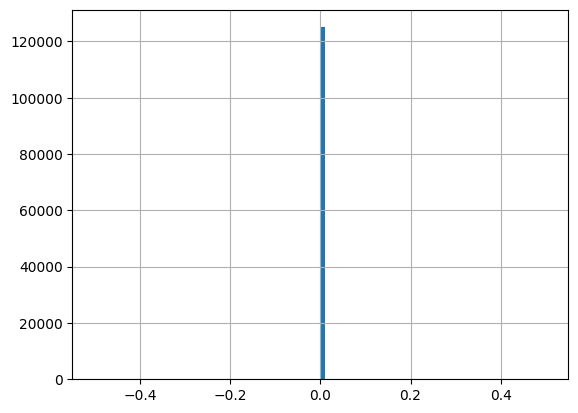

In [133]:
(baseline_scenario_anemia_yld_rates - intervention_anemia_yld_rates).anemic_yld_rate.hist(bins=100)

In [134]:
zero_fort_scenario_ylds = (
    zero_fort_scenario_anemia_yld_rates.anemic_yld_rate.unstack("draw").mean(axis=1)
    * non_pregnant_pop
)
zero_fort_scenario_ylds

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  1801.271863
                               2                  1419.783311
                               3                  1244.355229
                               4                  1059.997610
                               5                   769.541848
                                                     ...     
Male    95.0       125.000000  1                   827.604317
                               2                   844.438359
                               3                   868.092670
                               4                   894.100061
                               5                  1059.690219
Length: 250, dtype: float64

In [135]:
baseline_scenario_ylds = (
    baseline_scenario_anemia_yld_rates.anemic_yld_rate.unstack("draw").mean(axis=1)
    * non_pregnant_pop
)
baseline_scenario_ylds

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  1720.911482
                               2                  1348.978289
                               3                  1186.964625
                               4                  1014.742359
                               5                   748.952085
                                                     ...     
Male    95.0       125.000000  1                   808.131007
                               2                   825.228064
                               3                   850.786851
                               4                   878.164257
                               5                  1048.862621
Length: 250, dtype: float64

In [136]:
intervention_scenarios_ylds = (
    intervention_anemia_yld_rates.anemic_yld_rate.unstack("draw").mean(axis=1)
    * non_pregnant_pop
)
intervention_scenarios_ylds

sex     age_start  age_end     wealth_quintile  scenario    
Female  0.0        0.019178    1                intervention    1720.911482
                               2                intervention    1348.978289
                               3                intervention    1186.964625
                               4                intervention    1014.742359
                               5                intervention     748.952085
                                                                   ...     
Male    95.0       125.000000  1                intervention     808.131007
                               2                intervention     825.228064
                               3                intervention     850.786851
                               4                intervention     878.164257
                               5                intervention    1048.862621
Length: 250, dtype: float64

In [137]:
(
    baseline_scenario_ylds.loc[("Female", 25, 30, 1)].mean()
    - intervention_scenarios_ylds.loc[("Female", 25, 30, 1)].mean()
)

0.0

In [138]:
(
    baseline_scenario_ylds.groupby(["wealth_quintile"]).sum()
    - intervention_scenarios_ylds.groupby(["scenario", "wealth_quintile"]).sum()
)

scenario      wealth_quintile
intervention  1                  0.0
              2                  0.0
              3                  0.0
              4                  0.0
              5                  0.0
dtype: float64

In [139]:
ylds = pd.concat(
    [
        zero_fort_scenario_ylds.rename("value").reset_index().assign(scenario="zero"),
        baseline_scenario_ylds.rename("value").reset_index().assign(scenario="baseline"),
        intervention_scenarios_ylds.rename("value").reset_index(),
    ],
    ignore_index=True,
)
ylds

,sex,age_start,age_end,wealth_quintile,value,scenario
0,Female,0.0,0.019178,1,1801.271863,zero
1,Female,0.0,0.019178,2,1419.783311,zero
2,Female,0.0,0.019178,3,1244.355229,zero
3,Female,0.0,0.019178,4,1059.997610,zero
4,Female,0.0,0.019178,5,769.541848,zero
...,...,...,...,...,...,...
745,Male,95.0,125.000000,1,808.131007,intervention
746,Male,95.0,125.000000,2,825.228064,intervention
747,Male,95.0,125.000000,3,850.786851,intervention
748,Male,95.0,125.000000,4,878.164257,intervention


In [140]:
results_dir = f"./results/{vehicle.lower()}/{location.lower()}"

In [141]:
path = f"{results_dir}/ylds.parquet"
pathlib.Path(path).parent.mkdir(exist_ok=True, parents=True)
ylds.to_parquet(path)

In [142]:
zero_fort_anemia_prevalence = zero_fort_scenario_anemia_by_severity["anemic"].unstack("draw").mean(axis=1)
zero_fort_anemia_prevalence

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  0.965487
                               2                  0.947353
                               3                  0.940266
                               4                  0.917220
                               5                  0.900539
                                                    ...   
Male    95.0       125.000000  1                  0.784717
                               2                  0.772893
                               3                  0.765232
                               4                  0.762443
                               5                  0.763989
Length: 250, dtype: float64

In [143]:
baseline_anemia_prevalence = baseline_scenario_anemia_by_severity["anemic"].unstack("draw").mean(axis=1)
baseline_anemia_prevalence

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  0.956836
                               2                  0.934763
                               3                  0.927694
                               4                  0.903500
                               5                  0.891290
                                                    ...   
Male    95.0       125.000000  1                  0.773455
                               2                  0.761904
                               3                  0.755403
                               4                  0.753876
                               5                  0.759330
Length: 250, dtype: float64

In [144]:
zero_fort_anemia_cases = zero_fort_anemia_prevalence.mul(non_pregnant_pop, axis=0)
zero_fort_anemia_cases

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  47936.142149
                               2                  41281.501854
                               3                  36378.268813
                               4                  33424.279506
                               5                  26298.067393
                                                      ...     
Male    95.0       125.000000  1                  11909.410763
                               2                  12249.198027
                               3                  12526.984211
                               4                  13163.809909
                               5                  16264.929961
Length: 250, dtype: float64

In [145]:
zero_fort_anemia_cases.sum() / non_pregnant_pop.sum()

0.4130474930130346

In [146]:
baseline_anemia_cases = baseline_anemia_prevalence.mul(non_pregnant_pop, axis=0)
baseline_anemia_cases

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  47506.632184
                               2                  40732.864550
                               3                  35891.867070
                               4                  32924.299297
                               5                  26027.967319
                                                      ...     
Male    95.0       125.000000  1                  11738.491902
                               2                  12075.044649
                               3                  12366.085541
                               4                  13015.900492
                               5                  16165.739891
Length: 250, dtype: float64

In [147]:
baseline_anemia_cases.sum() / non_pregnant_pop.sum()

0.39305882159397215

In [148]:
baseline_anemia_cases.groupby(["wealth_quintile"]).sum() / non_pregnant_pop.groupby(
    ["wealth_quintile"]
).sum()

wealth_quintile
1    0.438073
2    0.402306
3    0.394832
4    0.374073
5    0.357258
dtype: float64

In [149]:
intervention_anemia_prevalence = (
    intervention_scenarios_anemia_by_severity["anemic"].unstack("draw").mean(axis=1)
)
intervention_anemia_prevalence

sex     age_start  age_end     wealth_quintile  scenario    
Female  0.0        0.019178    1                intervention    0.956836
                               2                intervention    0.934763
                               3                intervention    0.927694
                               4                intervention    0.903500
                               5                intervention    0.891290
                                                                  ...   
Male    95.0       125.000000  1                intervention    0.773455
                               2                intervention    0.761904
                               3                intervention    0.755403
                               4                intervention    0.753876
                               5                intervention    0.759330
Length: 250, dtype: float64

In [150]:
anemia_prevalence = pd.concat(
    [
        zero_fort_anemia_prevalence.rename("value")
        .reset_index()
        .assign(scenario="zero"),
        baseline_anemia_prevalence.rename("value")
        .reset_index()
        .assign(scenario="baseline"),
        intervention_anemia_prevalence.rename("value").reset_index(),
    ],
    ignore_index=True,
)
anemia_prevalence

,sex,age_start,age_end,wealth_quintile,value,scenario
0,Female,0.0,0.019178,1,0.965487,zero
1,Female,0.0,0.019178,2,0.947353,zero
2,Female,0.0,0.019178,3,0.940266,zero
3,Female,0.0,0.019178,4,0.917220,zero
4,Female,0.0,0.019178,5,0.900539,zero
...,...,...,...,...,...,...
745,Male,95.0,125.000000,1,0.773455,intervention
746,Male,95.0,125.000000,2,0.761904,intervention
747,Male,95.0,125.000000,3,0.755403,intervention
748,Male,95.0,125.000000,4,0.753876,intervention


In [151]:
path = f"{results_dir}/anemia_prevalence.parquet"
pathlib.Path(path).parent.mkdir(exist_ok=True, parents=True)
anemia_prevalence.to_parquet(path)

In [152]:
intervention_anemia_cases = intervention_anemia_prevalence.mul(non_pregnant_pop, axis=0)
intervention_anemia_cases

sex     age_start  age_end     wealth_quintile  scenario    
Female  0.0        0.019178    1                intervention    47506.632184
                               2                intervention    40732.864550
                               3                intervention    35891.867070
                               4                intervention    32924.299297
                               5                intervention    26027.967319
                                                                    ...     
Male    95.0       125.000000  1                intervention    11738.491902
                               2                intervention    12075.044649
                               3                intervention    12366.085541
                               4                intervention    13015.900492
                               5                intervention    16165.739891
Length: 250, dtype: float64

In [153]:
intervention_anemia_cases.sum() / non_pregnant_pop.sum()

0.3930588215939722

In [154]:
intervention_anemia_cases.groupby(["wealth_quintile"]).sum() / non_pregnant_pop.groupby(
    ["wealth_quintile"]
).sum()

wealth_quintile
1    0.438073
2    0.402306
3    0.394832
4    0.374073
5    0.357258
dtype: float64

In [155]:
(
    baseline_anemia_cases.groupby(["wealth_quintile"]).sum()
    - intervention_anemia_cases.groupby(["wealth_quintile"]).sum()
).map(lambda x: f"{round(x):,.0f}")

wealth_quintile
1    0
2    0
3    0
4    0
5    0
dtype: object

In [156]:
anemia_cases = pd.concat(
    [
        zero_fort_anemia_cases.rename("value").reset_index().assign(scenario="zero"),
        baseline_anemia_cases.rename("value").reset_index().assign(scenario="baseline"),
        intervention_anemia_cases.rename("value").reset_index(),
    ],
    ignore_index=True,
)
anemia_cases

,sex,age_start,age_end,wealth_quintile,value,scenario
0,Female,0.0,0.019178,1,47936.142149,zero
1,Female,0.0,0.019178,2,41281.501854,zero
2,Female,0.0,0.019178,3,36378.268813,zero
3,Female,0.0,0.019178,4,33424.279506,zero
4,Female,0.0,0.019178,5,26298.067393,zero
...,...,...,...,...,...,...
745,Male,95.0,125.000000,1,11738.491902,intervention
746,Male,95.0,125.000000,2,12075.044649,intervention
747,Male,95.0,125.000000,3,12366.085541,intervention
748,Male,95.0,125.000000,4,13015.900492,intervention


In [157]:
path = f"{results_dir}/anemia_cases.parquet"
pathlib.Path(path).parent.mkdir(exist_ok=True, parents=True)
anemia_cases.to_parquet(path)